# Actividad 1

## Primer lectura de la colección Time

Con la colección "Time", consistente de 423 documentos con 83 consultas asociadas con sus correspondientes juicios de relevancia, hacer lo que se pide en el readme

### Formato de la colección

TIME.ALL es un solo archivo con los 423 documentos concatenados... 
En todo el file hay tags de *TEXT y *STOP
Un doc va desde su TEXT inicial hasta el siguiente y el final del file es el STOP

In [229]:
from pathlib import Path
import string
from IPython.display import display
import numpy as np
from nltk.stem import PorterStemmer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter
import pandas as pd
import os
import time


RUTA_COLECCION = Path("../time")
ARCHIVO_DOCUMENTOS = RUTA_COLECCION / "TIME.ALL"

# MARKERS
MARCA_DOCUMENTO = "*TEXT"
MARCA_FIN = "*STOP"


In [230]:
def parse_hdr(linea):
    """
    Extrae los campos de una linea *TEXT

    Inputs:
    -------
    linea: Linea completa que empieza con el marcador *TEXT

    Returns:
    -------
    dict: Llaves id, fecha y pagina, las tres como cadena

    """
    campos = linea.split()
    return {
        "id": campos[1],
        "fecha": "/".join(campos[2:-2]),
        "pagina": campos[-1],
    }

In [231]:
def leer_documentos(ruta):
    """
    Separa TIME.ALL en sus documentos.
    Recorre el archivo una sola vez acumulando lineas hasta topar con
    el siguiente marcador

    Inputs:
    -------
    ruta: Ruta al archivo TIME.ALL

    Returns:
    -------
    list: Un dict por documento, con id, fecha, pagina y texto

    """
    docs = []
    actual = None
    cuerpo = []

    for line in ruta.read_text(encoding="ascii").splitlines():
        line = line.strip()

        if line.startswith(MARCA_DOCUMENTO):
            if actual is not None:
                actual["texto"] = " ".join(cuerpo)
                docs.append(actual)
            actual = parse_hdr(line)
            cuerpo = []
        elif line == MARCA_FIN:
            break
        elif line:
            cuerpo.append(line)

    # El *STOP cierra el ultimo documento, pero si el archivo terminara
    # sin el, el que quedo abierto se guarda de todas formas
    if actual is not None:
        actual["texto"] = " ".join(cuerpo)
        docs.append(actual)

    return docs

In [232]:
docs = leer_documentos(ARCHIVO_DOCUMENTOS)

print(f"documentos recuperados: {len(docs)}")

print("\n\n--- SANITY CHECK ---\n")
print(f"id: {docs[0]['id']}")
print(f"fecha: {docs[0]['fecha']}")
print(f"pagina: {docs[0]['pagina']}")
print(f"largo: {len(docs[0]['texto'])} caracteres")
print()
print(f"texto original: {docs[0]['texto'][:300]} ...")

documentos recuperados: 423


--- SANITY CHECK ---

id: 017
fecha: 01/04/63
pagina: 020
largo: 5649 caracteres

texto original: THE ALLIES AFTER NASSAU IN DECEMBER 1960, THE U.S . FIRST PROPOSED TO HELP NATO DEVELOP ITS OWN NUCLEAR STRIKE FORCE . BUT EUROPE MADE NO ATTEMPT TO DEVISE A PLAN . LAST WEEK, AS THEY STUDIED THE NASSAU ACCORD BETWEEN PRESIDENT KENNEDY AND PRIME MINISTER MACMILLAN, EUROPEANS SAW EMERGING THE FIRST O ...


### Hasta aqui tenemos los docs recuperados... pero los organizamos en un diccionario/tabla hash pq los vamos a recorrer muchas veces y asi, para que sea optimo. Ahora procesaremos los datos

## Eliminacion de palabras vacias

In [233]:
RUTA_COLECCION = Path("../time")
ARCHIVO_NULL_W = RUTA_COLECCION / "TIME.STP"
NULL_WORDS = set()

with open(ARCHIVO_NULL_W) as f:
    NULL_WORDS = {linea.strip().lower() for linea in f if linea.strip()}

print(f"palabras nulas cargadas: {len(NULL_WORDS)}")

palabras nulas cargadas: 340


In [234]:
def limpiar_token(token):
    """
    Quita laos signos de puntuacion pegada a los extremos de una 
    palabra

    Inputs:
    -------
    token: Palabra tal como salio de partir el texto por espacios

    Returns:
    -------
    str: El token sin signos de punt

    """
    return token.strip(string.punctuation)


def eliminar_palabras(doc_txt):
    """
    Elimina las palabras vacias del texto del documento

    Inputs:
    -------
    doc_txt: Un string que representa el texto del documento

    Returns:
    -------
    str: El mismo texto, sin palabras vacias ni puntuacion suelta

    """
    limpios = (limpiar_token(palabra) for palabra in doc_txt.split())
    return " ".join(
        palabra
        for palabra in limpios
        if palabra and palabra.lower() not in NULL_WORDS
    )


In [235]:
# guardams en otro atributa ara comparar despues
vc = 0
for doc in docs:
    doc["texto_nn"] = eliminar_palabras(doc["texto"])
    vc += 1

print(f"documentos procesados (eliminar palabras nulas): {vc}")


print("\n\n--- SANITY CHECK ---\n")
print(f"id: {docs[0]['id']}")
print(f"fecha: {docs[0]['fecha']}")
print(f"pagina: {docs[0]['pagina']}")
print(f"largo: {len(docs[0]['texto'])} caracteres")
print(f"texto original: {len(docs[0]['texto'].split())} palabras")
print(f"texto sin nulos: {len(docs[0]['texto_nn'].split())} palabras")
print()
print(f"texto original: {docs[0]['texto'][:300]} ...")
print(f"texto sin nulos: {docs[0]['texto_nn'][:300]} ...")


documentos procesados (eliminar palabras nulas): 423


--- SANITY CHECK ---

id: 017
fecha: 01/04/63
pagina: 020
largo: 5649 caracteres
texto original: 980 palabras
texto sin nulos: 445 palabras

texto original: THE ALLIES AFTER NASSAU IN DECEMBER 1960, THE U.S . FIRST PROPOSED TO HELP NATO DEVELOP ITS OWN NUCLEAR STRIKE FORCE . BUT EUROPE MADE NO ATTEMPT TO DEVISE A PLAN . LAST WEEK, AS THEY STUDIED THE NASSAU ACCORD BETWEEN PRESIDENT KENNEDY AND PRIME MINISTER MACMILLAN, EUROPEANS SAW EMERGING THE FIRST O ...
texto sin nulos: ALLIES NASSAU DECEMBER 1960 U.S PROPOSED HELP NATO DEVELOP NUCLEAR STRIKE FORCE EUROPE ATTEMPT DEVISE PLAN STUDIED NASSAU ACCORD PRESIDENT KENNEDY PRIME MINISTER MACMILLAN EUROPEANS SAW EMERGING OUTLINES NUCLEAR NATO U.S WANTS SUPPORT SPRANG ANGLO-U.S CRISIS CANCELLATION BUG-RIDDEN SKYBOLT MISSILE U ...


## Truncamiento con el algoritmo de Porter

El algoritmo de Porter es basicamente un truncador de palabras en ingles, que no usa diccinario ni es un lematizaor.
se basa en la medida m. Cada palabra se ve como C(VC)^mV, donde C es una racha de consonantes y V de vocales. m cuenta cuantas veces se repite el par VC, o sea qué tan larga es la raiz... convierte palabras asi 

- studies      -> studi
- happy        -> happi
- allies       -> alli
- university   -> univers


In [236]:


# algoritmo original
PORTER_ORIG = PorterStemmer(mode=PorterStemmer.ORIGINAL_ALGORITHM)

# nltk
PORTER_NLTK = PorterStemmer(mode=PorterStemmer.NLTK_EXTENSIONS)

# check de como funcionan
print("-- Comparacion rapida --\n")
for palabra in ["news", "dying", "proceed", "innings", "connected"]:
    print(f"   {palabra:12} orig={PORTER_ORIG.stem(palabra):10} "
          f"nltk={PORTER_NLTK.stem(palabra)}")

-- Comparacion rapida --

   news         orig=new        nltk=news
   dying        orig=dy         nltk=die
   proceed      orig=proce      nltk=proceed
   innings      orig=in         nltk=inning
   connected    orig=connect    nltk=connect


In [237]:
def truncar(doc_txt, stemmer):
    """
    Trunca cada palabra del texto con el stemmer que se le pase

    Inputs:
    -------
    doc_txt: texto
    stemmer: algoritmo con el que se trunca

    Returns:
    -------
    str: El mismo texto con cada palabra reducida a su raiz

    """
    return " ".join(stemmer.stem(palabra) for palabra in doc_txt.split())

In [238]:
vc = 0
for doc in docs:
    doc["texto_porter_orig"] = truncar(doc["texto_nn"], PORTER_ORIG)
    doc["texto_porter_nltk"] = truncar(doc["texto_nn"], PORTER_NLTK)
    vc += 1

print(f"documentos procesados(trunc): {vc}")

print("\n\n--- SANITY CHECK ---\n")
print(f"id: {docs[0]['id']}")
print(f"fecha: {docs[0]['fecha']}")
print(f"pagina: {docs[0]['pagina']}")
print(f"largo: {len(docs[0]['texto'])} caracteres")
print(f"texto original: {len(docs[0]['texto'].split())} palabras")
print(f"texto sin nulos: {len(docs[0]['texto_nn'].split())} palabras")
print(f"porter 1980: {len(docs[0]['texto_porter_orig'].split())} palabras")
print(f"porter nltk: {len(docs[0]['texto_porter_nltk'].split())} palabras")
print()
print(f"texto original: {docs[0]['texto'][:300]} ...")
print(f"texto sin nulos: {docs[0]['texto_nn'][:300]} ...")
print(f"porter 1980: {docs[0]['texto_porter_orig'][:300]} ...")
print(f"porter nltk : {docs[0]['texto_porter_nltk'][:300]} ...")


documentos procesados(trunc): 423


--- SANITY CHECK ---

id: 017
fecha: 01/04/63
pagina: 020
largo: 5649 caracteres
texto original: 980 palabras
texto sin nulos: 445 palabras
porter 1980: 445 palabras
porter nltk: 445 palabras

texto original: THE ALLIES AFTER NASSAU IN DECEMBER 1960, THE U.S . FIRST PROPOSED TO HELP NATO DEVELOP ITS OWN NUCLEAR STRIKE FORCE . BUT EUROPE MADE NO ATTEMPT TO DEVISE A PLAN . LAST WEEK, AS THEY STUDIED THE NASSAU ACCORD BETWEEN PRESIDENT KENNEDY AND PRIME MINISTER MACMILLAN, EUROPEANS SAW EMERGING THE FIRST O ...
texto sin nulos: ALLIES NASSAU DECEMBER 1960 U.S PROPOSED HELP NATO DEVELOP NUCLEAR STRIKE FORCE EUROPE ATTEMPT DEVISE PLAN STUDIED NASSAU ACCORD PRESIDENT KENNEDY PRIME MINISTER MACMILLAN EUROPEANS SAW EMERGING OUTLINES NUCLEAR NATO U.S WANTS SUPPORT SPRANG ANGLO-U.S CRISIS CANCELLATION BUG-RIDDEN SKYBOLT MISSILE U ...
porter 1980: alli nassau decemb 1960 u. propos help nato develop nuclear strike forc europ attempt devis plan studi nassau accor

### En q difieren los dos modos

Sobre la coleccion completa, cuantos tokens truncan distinto y cuales
son los casos mas frecuentes

In [239]:


discrepancias = Counter()
tokens_totales = 0

for doc in docs:
    for palabra in doc["texto_nn"].split():
        tokens_totales += 1
        orig = PORTER_ORIG.stem(palabra)
        nltk_ = PORTER_NLTK.stem(palabra)
        if orig != nltk_:
            discrepancias[(palabra.lower(), orig, nltk_)] += 1

distintos = sum(discrepancias.values())

print(f"tokens revisados: {tokens_totales}")
print(f"truncan distinto: {distintos}")
print(f"porcentaje: {100 * distintos / tokens_totales:.2f}%")
print(f"formas distintas: {len(discrepancias)}")


def mas_frecuentes(llave, n=15):
    """
    Cuenta los terminos mas frecuentes de una variante del texto.
    Minusculiza para que crudo y sin vacias sean comparables con las
    variantes de Porter, que ya vienen en minusculas.

    Inputs:
    -------
    llave: Atributo del documento del que se cuenta
    n: Cuantos terminos devolver

    Returns:
    -------
    list: Pares termino y frecuencia, del mas comun al menos

    """
    cuenta = Counter()
    for doc in docs:
        cuenta.update(doc[llave].lower().split())
    return cuenta.most_common(n)


VARIANTES = [
    ("crudo", "texto"),
    ("sin vacias", "texto_nn"),
    ("porter 1980", "texto_porter_orig"),
    ("porter nltk", "texto_porter_nltk"),
]
ANCHO = 14

tops = [mas_frecuentes(llave) for _, llave in VARIANTES]

print("\n\n--- TOP 15 POR VARIANTE ---\n")
print("".join(f"{nombre:<{ANCHO + 8}}" for nombre, _ in VARIANTES))
print("-" * ((ANCHO + 8) * len(VARIANTES)))
for fila in range(15):
    print("".join(f"{t[fila][0]:<{ANCHO}}{t[fila][1]:>6}  " for t in tops))

print("\n\n--- PORTER TRUNC VS NLTK ---\n")
print(f"{'palabra':<16}{'orig 1980':<14}{'nltk':<14}veces")
for (palabra, orig, nltk_), n in discrepancias.most_common(15):
    print(f"{palabra:<16}{orig:<14}{nltk_:<14}{n}")



tokens revisados: 124030
truncan distinto: 2151
porcentaje: 1.73%
formas distintas: 434


--- TOP 15 POR VARIANTE ---

crudo                 sin vacias            porter 1980           porter nltk           
----------------------------------------------------------------------------------------
the            15809  u.s              726  u.               726  u.               726  
.              12148  government       583  govern           609  govern           609  
of              7219  new              549  new              603  new              549  
to              6303  party            378  parti            434  parti            434  
a               5781  de               335  nation           426  nation           426  
and             5501  minister         310  communist        420  communist        420  
in              5244  west             310  red              377  red              377  
"               4946  war              280  minist           370  minist        

## Extraer vocabulario
El bocabulario es como el universo de palabras de la coleccion... voy a comparar los diferentes vocabularios (de la coleccion) con el eliminado de palabras nulas y el trunc con porter solo para ver como se comportan

In [240]:
# Cuanto encoge el vocabulario cada modo
vocab_raw = {p.lower() for doc in docs for p in doc["texto"].split()}
vocab_nn = {p.lower() for doc in docs for p in doc["texto_nn"].split()}
vocab_orig = {p for doc in docs for p in doc["texto_porter_orig"].split()}
vocab_nltk = {p for doc in docs for p in doc["texto_porter_nltk"].split()}

print(f"vocabulario sin truncar: {len(vocab_raw)}")
print(f"vocabulario sin truncar (sin nulos): {len(vocab_nn)}")
print(f"con porter 1980: {len(vocab_orig)}")
print(f"con porter de nltk: {len(vocab_nltk)}")
print()
print(f"reduccion 1980: {100 * (1 - len(vocab_orig)/len(vocab_nn)):.4f}%")
print(f"reduccion nltk: {100 * (1 - len(vocab_nltk)/len(vocab_nn)):.4f}%")

vocabulario sin truncar: 29418
vocabulario sin truncar (sin nulos): 23338
con porter 1980: 16675
con porter de nltk: 16623

reduccion 1980: 28.5500%
reduccion nltk: 28.7728%


ahora el de cada documento

In [241]:


def vocabulario_por_documento(docs, key):
    """
    Arma la tabla de vocabulario con su frecuencia de termino

    Inputs:
    -------
    docs: Lista de documentos, cada uno un dict
    key: Atributo del que se cuentan los terminos

    Returns:
    -------
    DataFrame: Columnas doc_id, termino y tf

    """
    filas = [
        (doc["id"], termino, tf)
        for doc in docs
        for termino, tf in Counter(doc[key].split()).items()
    ]
    return pd.DataFrame(filas, columns=["doc_id", "termino", "tf"])

In [242]:
# Obtenemos los vocabulario por documento d las 4 variantes

# Texto crudo
vocab_raw = vocabulario_por_documento(docs, "texto")
por_doc_raw = vocab_raw.groupby("doc_id").agg(
    terminos=("termino", "size"),
    tokens=("tf", "sum"),
)
mat_raw = (vocab_raw.pivot(index="doc_id", columns="termino", values="tf")
          .fillna(0)
          .astype("int32"))

# Texto sin nulos
vocab_nn = vocabulario_por_documento(docs, "texto_nn")
por_doc_nn = vocab_nn.groupby("doc_id").agg(
    terminos=("termino", "size"),
    tokens=("tf", "sum"),
)
mat_nn = (vocab_nn.pivot(index="doc_id", columns="termino", values="tf")
          .fillna(0)
          .astype("int32"))

# Texto con trunc Porter original
vocab_porter_o = vocabulario_por_documento(docs, "texto_porter_orig")
por_doc_porter_o = vocab_porter_o.groupby("doc_id").agg(
    terminos=("termino", "size"),
    tokens=("tf", "sum"),
)
mat_porter_o = (vocab_porter_o.pivot(index="doc_id", columns="termino", values="tf")
          .fillna(0)
          .astype("int32"))

# Texto con trunc Porter nltk
vocab_nltk = vocabulario_por_documento(docs, "texto_porter_nltk")
por_doc_nltk = vocab_nltk.groupby("doc_id").agg(
    terminos=("termino", "size"),
    tokens=("tf", "sum"),
)
mat_nltk = (vocab_nltk.pivot(index="doc_id", columns="termino", values="tf")
          .fillna(0)
          .astype("int32"))


In [243]:

print("--- Datos del vocabulario raw ---")
print(f"pares documento-termino: {len(vocab_raw)}")
print(f"documentos             : {vocab_raw['doc_id'].nunique()}")
print(f"vocabulario global     : {vocab_raw['termino'].nunique()}")
print(f"tokens totales         : {vocab_raw['tf'].sum()}")

print("\n--- Matriz de terminos por documento (texto raw) ---\n")
display(mat_raw.iloc[:10, :12])

print("\n--- Matriz de terminos por documento (cortada a terminos que aparecen) ---\n")
top = vocab_raw.groupby("termino")["tf"].sum().nlargest(15).index
display(mat_raw.loc[mat_raw.index[:12], top])

--- Datos del vocabulario raw ---
pares documento-termino: 140756
documentos             : 423
vocabulario global     : 29418
tokens totales         : 263749

--- Matriz de terminos por documento (texto raw) ---



termino,!,"!960,","""","""AFRICAN","""AND","""APARTHEID","""BASED","""BUT","""DEMOCRATIC","""DO","""ENTANGLEMENT","""ENTRY"
doc_id,,,,,,,,,,,,
017,0,0,20,0,0,0,0,0,0,0,0,0
018,0,0,8,0,0,0,0,0,0,0,0,0
019,0,0,2,0,0,0,0,0,0,0,0,0
020,0,0,6,0,0,0,0,0,0,0,0,0
021,1,0,21,0,0,0,0,0,0,0,0,0
023,0,0,7,0,0,0,0,0,0,0,0,0
024,0,0,10,0,0,0,0,0,0,0,0,0
025,0,0,2,0,0,0,0,0,0,0,0,0
026,0,0,21,0,0,0,0,0,0,0,0,0



--- Matriz de terminos por documento (cortada a terminos que aparecen) ---



termino,THE,.,OF,TO,A,AND,IN,"""",THAT,FOR,WAS,WITH,HIS,IS,HE
doc_id,,,,,,,,,,,,,,,
017,52,52,16,27,17,16,10,20,25,8,4,8,6,6,2
018,12,12,7,5,4,3,5,8,2,5,6,1,4,0,1
019,46,28,16,18,11,12,7,2,4,6,7,1,1,0,1
020,9,10,3,6,5,4,2,6,0,1,3,1,1,1,2
021,51,57,18,12,21,17,21,21,8,2,7,7,5,3,6
023,30,29,20,14,15,9,12,7,6,3,4,2,9,3,6
024,55,42,39,27,10,15,16,10,12,12,7,6,2,4,1
025,7,6,2,1,5,5,1,2,3,1,2,3,0,1,0
026,38,19,20,7,6,10,10,21,3,3,4,7,3,3,3


In [244]:
print("--- Datos del vocabulario nn ---")
print(f"pares documento-termino: {len(vocab_nn)}")
print(f"documentos             : {vocab_nn['doc_id'].nunique()}")
print(f"vocabulario global     : {vocab_nn['termino'].nunique()}")
print(f"tokens totales         : {vocab_nn['tf'].sum()}")

print("\n--- Matriz de terminos por documento (texto sin neutros) ---\n")
display(mat_nn.iloc[:10, :12])

print("\n--- Matriz de terminos por documento (cortada a terminos que aparecen) ---\n")
top = vocab_nn.groupby("termino")["tf"].sum().nlargest(15).index
display(mat_nn.loc[mat_nn.index[:12], top])


--- Datos del vocabulario nn ---
pares documento-termino: 96865
documentos             : 423
vocabulario global     : 23338
tokens totales         : 124030

--- Matriz de terminos por documento (texto sin neutros) ---



termino,00,1,"1,000","1,000,000","1,000-YEAR-OLD","1,000TH","1,000TO-1","1,014","1,100","1,100,000","1,193","1,200"
doc_id,,,,,,,,,,,,
017,0,1,0,0,0,0,0,0,0,0,0,0
018,0,0,0,0,0,0,0,0,0,0,0,0
019,0,0,0,0,0,0,0,0,0,0,0,0
020,0,0,0,0,0,0,0,0,0,0,0,0
021,0,0,0,0,0,0,0,0,0,0,0,0
023,0,0,0,0,0,0,0,0,0,0,0,0
024,0,0,0,0,0,0,0,0,0,0,0,0
025,0,0,0,0,0,0,0,0,0,0,0,0
026,0,0,0,0,0,0,0,0,0,0,0,0



--- Matriz de terminos por documento (cortada a terminos que aparecen) ---



termino,U.S,GOVERNMENT,NEW,PARTY,DE,MINISTER,WEST,SOUTH,WAR,COMMUNIST,RED,VIET,BRITISH,PRESIDENT,WORLD
doc_id,,,,,,,,,,,,,,,
017,15,2,0,0,11,2,1,0,0,0,0,0,4,2,0
018,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
019,2,0,0,0,0,0,3,0,0,3,0,0,0,0,0
020,3,0,0,0,0,0,0,0,0,0,1,0,0,0,0
021,2,1,0,0,0,0,0,0,1,0,1,0,2,0,0
023,2,0,1,1,0,0,1,0,0,0,0,0,0,2,0
024,1,1,0,0,0,1,0,0,1,0,2,0,1,0,0
025,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0
026,1,0,1,1,0,1,1,0,0,0,0,0,2,0,0


In [245]:
print("--- Datos del vocabulario porter_orig ---")
print(f"pares documento-termino: {len(vocab_porter_o)}")
print(f"documentos             : {vocab_porter_o['doc_id'].nunique()}")
print(f"vocabulario global     : {vocab_porter_o['termino'].nunique()}")
print(f"tokens totales         : {vocab_porter_o['tf'].sum()}")

print("\n--- Matriz de terminos por documento (texto porter_orig) ---\n")
display(mat_porter_o.iloc[:10, :12])

print("\n--- Matriz de terminos por documento (cortada a terminos que aparecen) ---\n")
top = vocab_porter_o.groupby("termino")["tf"].sum().nlargest(15).index
display(mat_porter_o.loc[mat_porter_o.index[:12], top])



--- Datos del vocabulario porter_orig ---
pares documento-termino: 92091
documentos             : 423
vocabulario global     : 16675
tokens totales         : 124030

--- Matriz de terminos por documento (texto porter_orig) ---



termino,00,1,"1,000","1,000,000","1,000-year-old","1,000th","1,000to-1","1,014","1,100","1,100,000","1,193","1,200"
doc_id,,,,,,,,,,,,
017,0,1,0,0,0,0,0,0,0,0,0,0
018,0,0,0,0,0,0,0,0,0,0,0,0
019,0,0,0,0,0,0,0,0,0,0,0,0
020,0,0,0,0,0,0,0,0,0,0,0,0
021,0,0,0,0,0,0,0,0,0,0,0,0
023,0,0,0,0,0,0,0,0,0,0,0,0
024,0,0,0,0,0,0,0,0,0,0,0,0
025,0,0,0,0,0,0,0,0,0,0,0,0
026,0,0,0,0,0,0,0,0,0,0,0,0



--- Matriz de terminos por documento (cortada a terminos que aparecen) ---



termino,u.,govern,new,parti,nation,communist,red,minist,de,forc,west,war,polit,south,countri
doc_id,,,,,,,,,,,,,,,
017,15,2,0,0,4,0,0,2,11,10,1,0,0,0,1
018,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
019,2,0,0,0,0,4,0,0,0,0,3,0,0,0,0
020,3,0,0,0,0,0,1,0,0,0,0,0,0,0,0
021,2,1,0,0,0,0,1,0,0,5,0,1,1,0,0
023,2,0,1,1,1,0,0,0,0,0,1,0,1,0,2
024,1,1,0,0,3,0,2,1,0,0,0,1,0,0,1
025,0,0,0,0,0,0,4,0,0,0,0,0,0,0,1
026,1,1,2,1,0,0,0,1,0,0,1,0,0,0,0


In [246]:
print("--- Datos del vocabulario porter_nltk ---")
print(f"pares documento-termino: {len(vocab_nltk)}")
print(f"documentos             : {vocab_nltk['doc_id'].nunique()}")
print(f"vocabulario global     : {vocab_nltk['termino'].nunique()}")
print(f"tokens totales         : {vocab_nltk['tf'].sum()}")

print("\n--- Matriz de terminos por documento (texto porter_nltk) ---\n")
display(mat_nltk.iloc[:10, :12])

print("\n--- Matriz de terminos por documento (cortada a terminos que aparecen) ---\n")
top = vocab_nltk.groupby("termino")["tf"].sum().nlargest(15).index
display(mat_nltk.loc[mat_nltk.index[:12], top])

--- Datos del vocabulario porter_nltk ---
pares documento-termino: 92040
documentos             : 423
vocabulario global     : 16623
tokens totales         : 124030

--- Matriz de terminos por documento (texto porter_nltk) ---



termino,00,1,"1,000","1,000,000","1,000-year-old","1,000th","1,000to-1","1,014","1,100","1,100,000","1,193","1,200"
doc_id,,,,,,,,,,,,
017,0,1,0,0,0,0,0,0,0,0,0,0
018,0,0,0,0,0,0,0,0,0,0,0,0
019,0,0,0,0,0,0,0,0,0,0,0,0
020,0,0,0,0,0,0,0,0,0,0,0,0
021,0,0,0,0,0,0,0,0,0,0,0,0
023,0,0,0,0,0,0,0,0,0,0,0,0
024,0,0,0,0,0,0,0,0,0,0,0,0
025,0,0,0,0,0,0,0,0,0,0,0,0
026,0,0,0,0,0,0,0,0,0,0,0,0



--- Matriz de terminos por documento (cortada a terminos que aparecen) ---



termino,u.,govern,new,parti,nation,communist,red,minist,de,forc,west,war,polit,south,countri
doc_id,,,,,,,,,,,,,,,
017,15,2,0,0,4,0,0,2,11,10,1,0,0,0,1
018,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
019,2,0,0,0,0,4,0,0,0,0,3,0,0,0,0
020,3,0,0,0,0,0,1,0,0,0,0,0,0,0,0
021,2,1,0,0,0,0,1,0,0,5,0,1,1,0,0
023,2,0,1,1,1,0,0,0,0,0,1,0,1,0,2
024,1,1,0,0,3,0,2,1,0,0,0,1,0,0,1
025,0,0,0,0,0,0,4,0,0,0,0,0,0,0,1
026,1,1,1,1,0,0,0,1,0,0,1,0,0,0,0


## Queries
Ahora procesmaos la queries y sacamos sus vectores

In [247]:
RUTA_COLECCION = Path("../time")
ARCHIVO_QUERIES = RUTA_COLECCION / "TIME.QUE"

MARCA_QUERY = "*FIND"

In [248]:
def leer_queries(ruta):
    """
    Separa TIME.QUE en sus consultas, reusando logica de docs

    Inputs:
    -------
    ruta: path al archivo TIME.QUE

    Returns:
    -------
    list: Un dict por consulta, con id y texto

    """
    queries, actual, cuerpo = [], None, []

    for line in ruta.read_text(encoding="ascii").splitlines():
        line = line.strip()

        if line.startswith(MARCA_QUERY):
            if actual is not None:
                actual["texto"] = " ".join(cuerpo)
                queries.append(actual)
            actual = {"id": line.split()[1]}
            cuerpo = []
        elif line == MARCA_FIN:
            break
        elif line:
            cuerpo.append(line)

    if actual is not None:
        actual["texto"] = " ".join(cuerpo)
        queries.append(actual)

    return queries


In [249]:
queries = leer_queries(ARCHIVO_QUERIES)

for q in queries:
    q["texto_nn"] = eliminar_palabras(q["texto"])
    q["texto_porter_orig"] = truncar(q["texto_nn"], PORTER_ORIG)
    q["texto_porter_nltk"] = truncar(q["texto_nn"], PORTER_NLTK)


In [250]:
print(f"queries ({len(queries)})")

print("\n\n--- SANITY CHECK ---\n")
for vc in range(0, min(5, len(queries))):
    print(f"\n--- Query {vc+1} ---")
    print(f"id: {queries[vc]['id']}")
    print(f"largo: {len(queries[vc]['texto'])} caracteres")
    print(f"query original: {len(queries[vc]['texto'].split())} palabras")
    print(f"query sin nulos: {len(queries[vc]['texto_nn'].split())} palabras")
    print(f"query 1980: {len(queries[vc]['texto_porter_orig'].split())} palabras")
    print(f"query nltk: {len(queries[vc]['texto_porter_nltk'].split())} palabras")
    print()
    print(f"texto original: {queries[vc]['texto']}")
    print(f"texto sin nulos: {queries[vc]['texto_nn']}")
    print(f"query 1980: {queries[vc]['texto_porter_orig']}")
    print(f"query nltk: {queries[vc]['texto_porter_nltk']}")

queries (83)


--- SANITY CHECK ---


--- Query 1 ---
id: 1
largo: 84 caracteres
query original: 13 palabras
query sin nulos: 9 palabras
query 1980: 9 palabras
query nltk: 9 palabras

texto original: KENNEDY ADMINISTRATION PRESSURE ON NGO DINH DIEM TO STOP SUPPRESSING THE BUDDHISTS .
texto sin nulos: KENNEDY ADMINISTRATION PRESSURE NGO DINH DIEM STOP SUPPRESSING BUDDHISTS
query 1980: kennedi administr pressur ngo dinh diem stop suppress buddhist
query nltk: kennedi administr pressur ngo dinh diem stop suppress buddhist

--- Query 2 ---
id: 2
largo: 121 caracteres
query original: 20 palabras
query sin nulos: 13 palabras
query 1980: 13 palabras
query nltk: 13 palabras

texto original: EFFORTS OF AMBASSADOR HENRY CABOT LODGE TO GET VIET NAM'S PRESIDENT DIEM TO CHANGE HIS POLICIES OF POLITICAL REPRESSION .
texto sin nulos: EFFORTS AMBASSADOR HENRY CABOT LODGE VIET NAM'S PRESIDENT DIEM CHANGE POLICIES POLITICAL REPRESSION
query 1980: effort ambassador henri cabot lodg viet nam' presid diem 

In [251]:
vocab_queries_raw = vocabulario_por_documento(queries, "texto")

# RAW
mat_queries_raw = (vocab_queries_raw
               .pivot(index="doc_id", columns="termino", values="tf")
               .reindex(columns=mat_raw.columns, fill_value=0)
               .fillna(0)
               .astype("int32")
               .rename_axis(index="query_id"))

mat_queries_raw = mat_queries_raw.reindex(sorted(mat_queries_raw.index, key=int))

vocab_queries_nn = vocabulario_por_documento(queries, "texto_nn")

# No nulos
mat_queries_nn = (vocab_queries_nn
               .pivot(index="doc_id", columns="termino", values="tf")
               .reindex(columns=mat_nn.columns, fill_value=0)
               .fillna(0)
               .astype("int32")
               .rename_axis(index="query_id"))

mat_queries_nn = mat_queries_nn.reindex(sorted(mat_queries_nn.index, key=int))

# porter 
vocab_queries_porter = vocabulario_por_documento(queries, "texto_porter_orig")

mat_queries_porter = (vocab_queries_porter
               .pivot(index="doc_id", columns="termino", values="tf")
               .reindex(columns=mat_porter_o.columns, fill_value=0)
               .fillna(0)
               .astype("int32")
               .rename_axis(index="query_id"))

mat_queries_porter = mat_queries_porter.reindex(sorted(mat_queries_porter.index, key=int))

# NLTK
vocab_queries_nltk = vocabulario_por_documento(queries, "texto_porter_nltk")

mat_queries_nltk = (vocab_queries_nltk
               .pivot(index="doc_id", columns="termino", values="tf")
               .reindex(columns=mat_nltk.columns, fill_value=0)
               .fillna(0)
               .astype("int32")
               .rename_axis(index="query_id"))

mat_queries_nltk = mat_queries_nltk.reindex(sorted(mat_queries_nltk.index, key=int))



In [252]:
print("--- Datos del vocabulario queries raw ---")
print(f"pares documento-termino: {len(vocab_queries_raw)}")
print(f"documentos             : {vocab_queries_raw['doc_id'].nunique()}")
print(f"vocabulario global     : {vocab_queries_raw['termino'].nunique()}")
print(f"tokens totales         : {vocab_queries_raw['tf'].sum()}")

print("\n--- Matriz de terminos por documento (texto raw) ---\n")
display(mat_queries_raw.iloc[:10, :12])

print("\n--- Matriz de terminos por documento (cortada a terminos que aparecen) ---\n")
top = vocab_queries_raw.groupby("termino")["tf"].sum().nlargest(15).index
display(mat_queries_raw.loc[mat_queries_raw.index[:12], top])



--- Datos del vocabulario queries raw ---
pares documento-termino: 1228
documentos             : 83
vocabulario global     : 552
tokens totales         : 1341

--- Matriz de terminos por documento (texto raw) ---



termino,!,"!960,","""","""AFRICAN","""AND","""APARTHEID","""BASED","""BUT","""DEMOCRATIC","""DO","""ENTANGLEMENT","""ENTRY"
query_id,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0



--- Matriz de terminos por documento (cortada a terminos que aparecen) ---



termino,.,THE,OF,IN,TO,AND,BY,ON,NATIONS,A,FOR,UNITED,WHICH,ITS,PRESIDENT
query_id,,,,,,,,,,,,,,,
1,1,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,1,0,2,0,2,0,0,0,0,0,0,0,0,0,1
3,1,2,2,2,0,0,0,0,0,0,0,1,0,0,0
4,2,1,0,1,0,0,0,0,0,0,0,0,1,0,1
5,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0
6,1,0,0,1,1,1,2,0,0,0,0,0,0,0,0
7,2,0,1,0,1,0,1,0,0,0,0,0,0,0,0
8,2,2,3,1,0,1,0,1,0,0,0,0,0,0,0
9,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0


In [253]:
print("--- Datos del vocabulario queries nn ---")
print(f"pares documento-termino: {len(vocab_queries_nn)}")
print(f"documentos             : {vocab_queries_nn['doc_id'].nunique()}")
print(f"vocabulario global     : {vocab_queries_nn['termino'].nunique()}")
print(f"tokens totales         : {vocab_queries_nn['tf'].sum()}")

print("\n--- Matriz de terminos por documento (texto nn) ---\n")
display(mat_queries_nn.iloc[:10, :12])

print("\n--- Matriz de terminos por documento (cortada a terminos que aparecen) ---\n")
top = vocab_queries_nn.groupby("termino")["tf"].sum().nlargest(15).index
display(mat_queries_nn.loc[mat_queries_nn.index[:12], top])

--- Datos del vocabulario queries nn ---
pares documento-termino: 697
documentos             : 83
vocabulario global     : 449
tokens totales         : 722

--- Matriz de terminos por documento (texto nn) ---



termino,00,1,"1,000","1,000,000","1,000-YEAR-OLD","1,000TH","1,000TO-1","1,014","1,100","1,100,000","1,193","1,200"
query_id,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0



--- Matriz de terminos por documento (cortada a terminos que aparecen) ---



termino,NATIONS,UNITED,PRESIDENT,PREMIER,U.S,AFRICAN,COMMUNIST,NEW,PARTY,SOUTH,SOVIET,COUNTRIES,FEDERATION,KHRUSHCHEV,MALAYSIA
query_id,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
7,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [254]:
print("--- Datos del vocabulario queries porter ---")
print(f"pares documento-termino: {len(vocab_queries_porter)}")
print(f"documentos             : {vocab_queries_porter['doc_id'].nunique()}")
print(f"vocabulario global     : {vocab_queries_porter['termino'].nunique()}")
print(f"tokens totales         : {vocab_queries_porter['tf'].sum()}")

print("\n--- Matriz de terminos por documento (texto porter) ---\n")
display(mat_queries_porter.iloc[:10, :12])

print("\n--- Matriz de terminos por documento (cortada a terminos que aparecen) ---\n")
top = vocab_queries_porter.groupby("termino")["tf"].sum().nlargest(15).index
display(mat_queries_porter.loc[mat_queries_porter.index[:12], top])

--- Datos del vocabulario queries porter ---
pares documento-termino: 695
documentos             : 83
vocabulario global     : 413
tokens totales         : 722

--- Matriz de terminos por documento (texto porter) ---



termino,00,1,"1,000","1,000,000","1,000-year-old","1,000th","1,000to-1","1,014","1,100","1,100,000","1,193","1,200"
query_id,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0



--- Matriz de terminos por documento (cortada a terminos que aparecen) ---



termino,nation,unit,presid,premier,propos,u.,parti,state,african,communist,countri,forc,involv,new,south
query_id,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
4,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1
5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
7,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [255]:
print("--- Datos del vocabulario queries nltk ---")
print(f"pares documento-termino: {len(vocab_queries_nltk)}")
print(f"documentos             : {vocab_queries_nltk['doc_id'].nunique()}")
print(f"vocabulario global     : {vocab_queries_nltk['termino'].nunique()}")
print(f"tokens totales         : {vocab_queries_nltk['tf'].sum()}")

print("\n--- Matriz de terminos por documento (texto nltk) ---\n")
display(mat_queries_nltk.iloc[:10, :12])

print("\n--- Matriz de terminos por documento (cortada a terminos que aparecen) ---\n")
top = vocab_queries_nltk.groupby("termino")["tf"].sum().nlargest(15).index
display(mat_queries_nltk.loc[mat_queries_nltk.index[:12], top])

--- Datos del vocabulario queries nltk ---
pares documento-termino: 695
documentos             : 83
vocabulario global     : 413
tokens totales         : 722

--- Matriz de terminos por documento (texto nltk) ---



termino,00,1,"1,000","1,000,000","1,000-year-old","1,000th","1,000to-1","1,014","1,100","1,100,000","1,193","1,200"
query_id,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0



--- Matriz de terminos por documento (cortada a terminos que aparecen) ---



termino,nation,unit,presid,premier,propos,u.,parti,state,african,communist,countri,forc,involv,new,south
query_id,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
4,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1
5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
7,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [256]:
def export_voc(vocab, ruta, prefijo="Doc", orden_numerico=False):
    """
    Escribe el vocabulario en el formato que pide el enunciado

    Inputs:
    -------
    vocab: DataFrame con columnas doc_id, termino y tf
    ruta: Archivo de salida
    prefijo: Lo que va antes del id, Doc o Query
    orden_numerico: True cuando los ids no traen ceros a la izquierda,
                    para que 10 no quede antes que 2

    Returns:
    -------
    int: Numero de lineas escritas

    """
    ids = vocab["doc_id"].unique()
    if orden_numerico:
        ids = sorted(ids, key=int)

    grupos = dict(tuple(vocab.groupby("doc_id", sort=False)))

    with open(ruta, "w", encoding="utf-8") as salida:
        for id_ in ids:
            grupo = grupos[id_].sort_values(
                ["tf", "termino"], ascending=[False, True])
            pares = " ".join(f"{t} {n}" for t, n
                             in zip(grupo["termino"], grupo["tf"]))
            salida.write(f"{prefijo}{id_} {pares}\n")

    return len(ids)


In [257]:
salidas = [
    (vocab_raw,     "vocab_raw.txt",     "Doc",   False),
    (vocab_nn,      "vocab_nn.txt",      "Doc",   False),
    (vocab_porter_o,  "vocab_porter.txt",  "Doc",   False),
    (vocab_queries_raw, "vocab_queries_raw.txt", "Query", True),
    (vocab_queries_nn, "vocab_queries_nn.txt", "Query", True),
    (vocab_queries_porter, "vocab_queries_porter.txt", "Query", True),
    (vocab_queries_nltk, "vocab_queries_nltk.txt", "Query", True),
]

for vocab, nombre, prefijo, num in salidas:
    n = export_voc(vocab, nombre, prefijo, num)
    print(f"{nombre:22} {n:4} lineas")


vocab_raw.txt           423 lineas
vocab_nn.txt            423 lineas
vocab_porter.txt        423 lineas
vocab_queries_raw.txt    83 lineas
vocab_queries_nn.txt     83 lineas
vocab_queries_porter.txt   83 lineas
vocab_queries_nltk.txt   83 lineas


# Actividad 2

Partiendo de la tarea anterior para la colección Time, donde ya se cuenta con el
vocabulario de cada documento y de las consultas:

1) Conjuntar el vocabulario de la colección, calculando la frecuencia de documento
(número de documentos en que aparece) de cada término (aquí no intervienen las
consultas). A partir del vocabulario de la colección, construir los vectores de cada
documento con un pesado tf-idf y cada consulta con pesado binario.

2) Realizar la recuperación de información para las primeras 10 consultas, obteniendo
los documentos que tienen una medida de similitud coseno distinta de cero y
ordenándolos decrecientemente. Calcular los niveles de recuerdo y precisión alcanzados
según el orden obtenido en la recuperación en cada una de las consultas. Para esto se
usarán los juicios de relevancia de la colección.

## Matriz con tf-idf
A partir de ahora solo utilizare los conjuntos de datos de las ppalabras truncadas con Porter y NLTK (que ya habia construido en la actividad pasada) y, a partir de estas construire la coleccion o matriz con el tf-idf (y tambien utilizare okapi-bm25 solo para compara)

In [258]:
mat_nltk

termino,00,1,"1,000","1,000,000","1,000-year-old","1,000th","1,000to-1","1,014","1,100","1,100,000",...,zodiac,zola,zone,zoo,zoom,zorin,zorza,zu,zulfikar,zurich
doc_id,,,,,,,,,,,,,,,,,,,,,
017,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
018,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
019,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
021,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
560,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
561,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [259]:
mat_porter_o

termino,00,1,"1,000","1,000,000","1,000-year-old","1,000th","1,000to-1","1,014","1,100","1,100,000",...,zodiac,zola,zone,zoo,zoom,zorin,zorza,zu,zulfikar,zurich
doc_id,,,,,,,,,,,,,,,,,,,,,
017,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
018,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
019,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
021,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
560,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
561,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Metodos aux

Para recordar rapido

- *tf-idf*: tf se normaliza dividiendo entre la frecuencia del termino ma frecuente de ese documento, para que un documento largo no tenga pesos mas grandes solo por ser largo. El idf usa logaritmo natural; la base solo escala todo por igual y no cambia el orden (es la combinacion de los dos que vimos en clase)

- *OKAPI-BM25*: Corrige las dos fallas de tf-idf: la frecuencia entra saturada, asi que pasar de una a dos ocurrencias pesa mucho mas que de cien a ciento una, y la longitud del documento se compara contra la longitud promedio de la coleccion en vez de contra el pico propio

In [260]:

# Parametros clasicos de Okapi BM25. k1 controla que tan rapido satura
# la frecuencia y b cuanto se corrige por la longitud del documento
K1_BM25 = 1.2
B_BM25 = 0.75

def frecuencia_de_documento(mat):
    """
    Cuenta en cuantos documentos aparece cada termino

    Inputs:
    -------
    mat: Matriz documento por termino con las frecuencias crudas

    Returns:
    -------
    Series: n_i por termino, indexada por el termino

    """
    return (mat > 0).sum(axis=0)


def pesar_tfidf(mat):
    """
    Construye la matriz con pesado tf-idf

    Inputs:
    -------
    mat: Matriz documento por termino con las frecuencias crudas

    Returns:
    -------
    DataFrame: Misma forma que mat, con los pesos en float32

    """
    n_docs = len(mat)
    idf = np.log(n_docs / frecuencia_de_documento(mat))

    # Un documento vacio daria division entre cero; su fila sale en 0
    pico = mat.max(axis=1).replace(0, 1)
    tf = mat.div(pico, axis=0)

    return tf.mul(idf, axis=1).astype("float32")


def pesar_bm25(mat, k1=K1_BM25, b=B_BM25):
    """
    Construye la matriz con pesado Okapi BM25

    Inputs:
    -------
    mat: Matriz documento por termino con las frecuencias crudas
    k1: Punto de saturacion de la frecuencia
    b: Cuanto se penaliza que el documento sea largo, de 0 a 1

    Returns:
    -------
    DataFrame: Misma forma que mat, con los pesos en float32

    """
    n_docs = len(mat)
    n_i = frecuencia_de_documento(mat)

    # El +1 mantiene el idf no negativo. Sin el, un termino que salga
    # en mas de la mitad de la coleccion pesaria negativo y restaria
    idf = np.log((n_docs - n_i + 0.5) / (n_i + 0.5) + 1)

    largo = mat.sum(axis=1)
    norma = k1 * (1 - b + b * largo / largo.mean())

    # Donde mat vale 0 el numerador es 0 y el denominador es norma > 0,
    # asi que la celda queda en 0 sin division indefinida
    saturada = (mat * (k1 + 1)).div(mat.add(norma, axis=0))

    return saturada.mul(idf, axis=1).astype("float32")




#### Construyendo

In [261]:
# Las cuatro matrices pesadas de la actividad 2
mat_porter_tfidf = pesar_tfidf(mat_porter_o)
mat_porter_bm25 = pesar_bm25(mat_porter_o)
mat_nltk_tfidf = pesar_tfidf(mat_nltk)
mat_nltk_bm25 = pesar_bm25(mat_nltk)

for nombre, m in [("porter tf-idf", mat_porter_tfidf),
                  ("porter bm25", mat_porter_bm25),
                  ("nltk tf-idf", mat_nltk_tfidf),
                  ("nltk bm25", mat_nltk_bm25)]:
    print(f"{nombre:14} {m.shape[0]} x {m.shape[1]}"
          f"  no nulos {int((m != 0).sum().sum())}"
          f"  {m.memory_usage(deep=True).sum() / 1e6:.1f} MB")

porter tf-idf  423 x 16675  no nulos 92091  28.3 MB
porter bm25    423 x 16675  no nulos 92091  28.3 MB
nltk tf-idf    423 x 16623  no nulos 92040  28.2 MB
nltk bm25      423 x 16623  no nulos 92040  28.2 MB


#### Visualizando

In [262]:
mat_porter_tfidf

termino,00,1,"1,000","1,000,000","1,000-year-old","1,000th","1,000to-1","1,014","1,100","1,100,000",...,zodiac,zola,zone,zoo,zoom,zorin,zorza,zu,zulfikar,zurich
doc_id,,,,,,,,,,,,,,,,,,,,,
017,0.0,0.146482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
018,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
019,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
020,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
021,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
560,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
561,0.0,0.313889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [263]:
print("\n--- Coleccion TF-IDF sobre coleccion truncada con Porter Original ---\n")
top = mat_porter_tfidf.sum(axis=0).nlargest(15).index
display(mat_porter_tfidf.loc[mat_porter_tfidf.index[:12], top])


--- Coleccion TF-IDF sobre coleccion truncada con Porter Original ---



termino,u.,khrushchev,de,viet,soviet,parti,south,red,communist,chines,moscow,minist,west,govern,african
doc_id,,,,,,,,,,,,,,,
017,0.821626,0.000000,1.23982,0.0000,0.204868,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.123917,0.077638,0.080661,0.000000
018,0.000000,2.197225,0.00000,0.0000,0.512171,0.313809,0.000000,0.000000,0.307803,0.000000,0.585638,0.000000,0.000000,0.000000,0.000000
019,0.205406,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.000000,0.461704,0.000000,0.000000,0.000000,0.436714,0.000000,0.000000
020,0.616219,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.281848,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
021,0.096662,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.066317,0.000000,0.000000,0.000000,0.000000,0.000000,0.035586,0.000000
023,0.182583,0.000000,0.00000,0.0000,0.000000,0.104603,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.129397,0.000000,0.000000
024,0.051352,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.140924,0.000000,0.250540,0.000000,0.058086,0.000000,0.037810,0.000000
025,0.000000,0.000000,0.00000,0.0000,0.307303,0.000000,0.000000,0.901913,0.000000,0.400864,0.000000,0.000000,0.000000,0.000000,0.000000
026,0.117375,0.000000,0.00000,0.0000,0.000000,0.134490,0.000000,0.000000,0.000000,0.000000,0.000000,0.132768,0.166367,0.086422,0.000000


In [264]:
print("\n--- Coleccion OKAPI sobre coleccion truncada con Porter Original ---\n")
top = mat_porter_bm25.sum(axis=0).nlargest(15).index
display(mat_porter_bm25.loc[mat_porter_bm25.index[:12], top])


--- Coleccion OKAPI sobre coleccion truncada con Porter Original ---



termino,u.,parti,communist,red,minist,west,soviet,nation,presid,govern,forc,de,leader,british,south
doc_id,,,,,,,,,,,,,,,
017,1.626254,0.000000,0.000000,0.000000,1.114736,0.959879,1.840463,1.202410,1.300353,0.726338,1.820266,3.222558,0.876989,2.190198,0.000000
018,0.000000,1.273367,1.249051,0.000000,0.000000,0.000000,2.075522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
019,1.192445,0.000000,1.614270,0.000000,0.000000,1.904665,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
020,1.510535,0.000000,0.000000,1.559585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
021,1.038829,0.000000,0.000000,0.999510,0.000000,0.000000,0.000000,0.000000,0.000000,0.537121,1.638845,0.000000,0.000000,1.783652,0.000000
023,1.192445,1.019283,0.000000,0.000000,0.000000,1.260234,0.000000,0.838790,1.572981,0.000000,0.000000,0.000000,1.151407,0.000000,0.000000
024,0.715676,0.000000,0.000000,1.405761,0.809305,0.000000,0.000000,1.129256,0.000000,0.527326,0.000000,0.000000,0.000000,1.228803,0.000000
025,0.000000,0.000000,0.000000,2.166931,0.000000,0.000000,2.144365,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
026,0.927717,1.062655,0.000000,0.000000,1.049086,1.313858,0.000000,0.000000,0.000000,0.683562,0.000000,0.000000,0.000000,2.104971,0.000000


In [265]:
print("\n--- Coleccion TF-IDF sobre coleccion truncada con NLTK ---\n")
top = mat_nltk_tfidf.sum(axis=0).nlargest(15).index
display(mat_nltk_tfidf.loc[mat_nltk_tfidf.index[:12], top])


--- Coleccion TF-IDF sobre coleccion truncada con NLTK ---



termino,u.,khrushchev,de,viet,soviet,parti,south,red,communist,chines,moscow,minist,west,govern,african
doc_id,,,,,,,,,,,,,,,
017,0.821626,0.000000,1.23982,0.0000,0.204868,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.123917,0.077638,0.080661,0.000000
018,0.000000,2.197225,0.00000,0.0000,0.512171,0.313809,0.000000,0.000000,0.307803,0.000000,0.585638,0.000000,0.000000,0.000000,0.000000
019,0.205406,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.000000,0.461704,0.000000,0.000000,0.000000,0.436714,0.000000,0.000000
020,0.616219,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.281848,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
021,0.096662,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.066317,0.000000,0.000000,0.000000,0.000000,0.000000,0.035586,0.000000
023,0.182583,0.000000,0.00000,0.0000,0.000000,0.104603,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.129397,0.000000,0.000000
024,0.051352,0.000000,0.00000,0.0000,0.000000,0.000000,0.000000,0.140924,0.000000,0.250540,0.000000,0.058086,0.000000,0.037810,0.000000
025,0.000000,0.000000,0.00000,0.0000,0.307303,0.000000,0.000000,0.901913,0.000000,0.400864,0.000000,0.000000,0.000000,0.000000,0.000000
026,0.117375,0.000000,0.00000,0.0000,0.000000,0.134490,0.000000,0.000000,0.000000,0.000000,0.000000,0.132768,0.166367,0.086422,0.000000


In [266]:
print("\n--- Coleccion OKAPI sobre coleccion truncada con NLTK ---\n")
top = mat_nltk_bm25.sum(axis=0).nlargest(15).index
display(mat_nltk_bm25.loc[mat_nltk_bm25.index[:12], top])


--- Coleccion OKAPI sobre coleccion truncada con NLTK ---



termino,u.,parti,communist,red,minist,west,soviet,nation,presid,govern,forc,de,leader,british,south
doc_id,,,,,,,,,,,,,,,
017,1.626254,0.000000,0.000000,0.000000,1.114736,0.959879,1.840463,1.202410,1.300353,0.726338,1.820266,3.222558,0.876989,2.190198,0.000000
018,0.000000,1.273367,1.249051,0.000000,0.000000,0.000000,2.075522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
019,1.192445,0.000000,1.614270,0.000000,0.000000,1.904665,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
020,1.510535,0.000000,0.000000,1.559585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
021,1.038829,0.000000,0.000000,0.999510,0.000000,0.000000,0.000000,0.000000,0.000000,0.537121,1.638845,0.000000,0.000000,1.783652,0.000000
023,1.192445,1.019283,0.000000,0.000000,0.000000,1.260234,0.000000,0.838790,1.572981,0.000000,0.000000,0.000000,1.151407,0.000000,0.000000
024,0.715676,0.000000,0.000000,1.405761,0.809305,0.000000,0.000000,1.129256,0.000000,0.527326,0.000000,0.000000,0.000000,1.228803,0.000000
025,0.000000,0.000000,0.000000,2.166931,0.000000,0.000000,2.144365,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
026,0.927717,1.062655,0.000000,0.000000,1.049086,1.313858,0.000000,0.000000,0.000000,0.683562,0.000000,0.000000,0.000000,2.104971,0.000000


## IR de las consultas

Se definen varias funciones auxiliares...

La similitud coseno esta tomada como lo vimos en clase

Y las expresiones de recall y acc son igual las que vimos en clase

In [267]:
def cargar_relevancias(path, orden_docs):
    """
    Lee TIME.REL y traduce sus numeros a ids de documento

    Inputs:
    -------
    path: Archivo TIME.REL de la coleccion
    orden_docs: Ids de los documentos en el orden en que aparecen en
                TIME.ALL, o sea [d["id"] for d in docs]

    Returns:
    -------
    dict: Id de consulta -> conjunto de ids de documento relevantes

    """
    posicion = {str(i + 1): doc for i, doc in enumerate(orden_docs)}

    relevancias = {}
    for linea in open(path, encoding="utf-8"):
        campos = linea.split()
        if not campos:
            continue
        relevancias[campos[0]] = {posicion[c] for c in campos[1:]
                                  if c in posicion}

    return relevancias

relevancias = cargar_relevancias(path=RUTA_COLECCION / "TIME.REL",
                                 orden_docs=[d["id"] for d in docs])


In [268]:
relevancias

{'1': {'334', '363', '390', '396', '414', '418', '434'},
 '2': {'418', '434'},
 '3': {'418', '470', '492', '521'},
 '4': {'498', '511', '521', '548', '561'},
 '5': {'480', '498', '521', '535', '561'},
 '6': {'320', '334', '363', '390', '396', '414', '415', '418', '434'},
 '7': {'522', '546'},
 '8': {'443', '479'},
 '9': {'094', '203', '204', '303', '335', '404', '443', '479'},
 '10': {'094', '204', '303', '335', '443', '479'},
 '11': {'253', '256'},
 '12': {'094', '203', '204', '303', '335', '443', '479'},
 '13': {'122', '227', '243'},
 '14': {'335'},
 '15': {'133', '160', '176', '221'},
 '16': {'226', '227', '300'},
 '17': {'389', '479'},
 '18': {'477'},
 '19': {'138', '140', '253', '333', '459'},
 '20': {'477'},
 '21': {'391', '407'},
 '22': {'065', '477'},
 '23': set(),
 '24': {'407'},
 '25': {'446'},
 '26': {'407'},
 '27': {'341', '380', '392'},
 '28': {'247', '278', '331', '348', '485'},
 '29': {'250', '425'},
 '30': {'315', '324', '337', '369', '417'},
 '31': {'071', '088', '116'

In [269]:
def mostrar_relevancias(q, r, count=10):
    """
    Imprime cada consulta junto a los ids de sus relevantes

    Inputs:
    -------
    q: Lista de dicts de consulta, con id y texto
    r: Dict de id de consulta a conjunto de ids relevantes
    count: Cuantas consultas imprimir

    Returns:
    -------

    """
    for q in q[:count]:
        docs = sorted(r.get(q["id"], set()))
        print(f"Query {q['id']}  ({len(docs)} relevantes)")
        print(f"  texto : {q['texto']}")
        print(f"  docs  : {', '.join(docs) if docs else '(ninguno)'}")
        print()

mostrar_relevancias(queries, relevancias, count=10)

Query 1  (7 relevantes)
  texto : KENNEDY ADMINISTRATION PRESSURE ON NGO DINH DIEM TO STOP SUPPRESSING THE BUDDHISTS .
  docs  : 334, 363, 390, 396, 414, 418, 434

Query 2  (2 relevantes)
  texto : EFFORTS OF AMBASSADOR HENRY CABOT LODGE TO GET VIET NAM'S PRESIDENT DIEM TO CHANGE HIS POLICIES OF POLITICAL REPRESSION .
  docs  : 418, 434

Query 3  (4 relevantes)
  texto : NUMBER OF TROOPS THE UNITED STATES HAS STATIONED IN SOUTH VIET NAM AS COMPARED WITH THE NUMBER OF TROOPS IT HAS STATIONED IN WEST GERMANY .
  docs  : 418, 470, 492, 521

Query 4  (5 relevantes)
  texto : U.S . POLICY TOWARD THE NEW REGIME IN SOUTH VIET NAM WHICH OVERTHREW PRESIDENT DIEM .
  docs  : 498, 511, 521, 548, 561

Query 5  (5 relevantes)
  texto : PERSONS INVOLVED IN THE VIET NAM COUP .
  docs  : 480, 498, 521, 535, 561

Query 6  (9 relevantes)
  texto : CEREMONIAL SUICIDES COMMITTED BY SOME BUDDHIST MONKS IN SOUTH VIET NAM AND WHAT THEY ARE SEEKING TO GAIN BY SUCH ACTS .
  docs  : 320, 334, 363, 390, 396, 414

In [270]:

def normalizar(mat):
    """
    Divide cada fila entre su norma euclidiana (normaliza)

    Inputs:
    -------
    mat: Matriz cuyas filas son vectores en el espacio de terminos

    Returns:
    -------
    DataFrame: Misma forma, con cada fila de norma 1 o de norma 0

    """
    norma = np.sqrt((mat.astype("float32") ** 2).sum(axis=1))
    return mat.div(norma.replace(0, 1), axis=0).astype("float32")


def cosine_sim(mat_docs, mat_q):
    """
    Similitud coseno de cada consulta contra cada documento

    Inputs:
    -------
    mat_docs: Matriz documento por termino, con el pesado que se quiera
    mat_q: Matriz consulta por termino, mismo vocabulario

    Returns:
    -------
    DataFrame: Consultas en las filas, documentos en las columnas

    """
    consultas = mat_q.reindex(columns=mat_docs.columns,
                              fill_value=0)
    docs_n = normalizar(mat_docs)
    consultas_n = normalizar(consultas)

    prod = consultas_n.to_numpy() @ docs_n.to_numpy().T

    dataframe = pd.DataFrame(prod,
                            index=consultas_n.index,
                            columns=docs_n.index)

    return dataframe


def recuperar(sim, id_q):
    """
    Ranking de una consulta

    Inputs:
    -------
    sim: Matriz de similitud que devuelve similitud_coseno
    id_q: Identificador de la consulta, de las filas de sim

    Returns:
    -------
    Series: Documentos recuperados con su coseno, en orden decreciente

    """
    fila = sim.loc[id_q]
    return fila[fila > 0].sort_values(ascending=False)


def acc_rec(ret, rel):
    """
    Accuracy y recall de un conjunto recuperado
    Accuracy es cuantos de los que traje son relevantes (precision), y recall es
    cuantos de los relevantes alcance a traer (recuerdo)

    Inputs:
    -------
    ret: Ids de documento devueltos por el sistema
    rel: Ids de documento relevantes segun los juicios

    Returns:
    -------
    tuple: (precision, recuerdo), ambos entre 0 y 1

    """
    ret = list(ret)
    rel = set(rel)
    aciertos = sum(1 for doc in ret if doc in rel)

    precision = aciertos / len(ret) if ret else 0.0
    recuerdo = aciertos / len(rel) if rel else 0.0

    return precision, recuerdo


def lvls_acc_rec(rank, rel):
    """
    Accuracy y recall en cada posicion del ranking

    Inputs:
    -------
    rank: Ids de documento en el orden que devolvio el sistema
    rel: Ids de documento relevantes segun los juicios

    Returns:
    -------
    DataFrame: Una fila por posicion, con accuracy y recall

    """
    rel = set(rel)
    total = len(rel)

    filas, aciertos = [], 0
    for posicion, doc in enumerate(rank, start=1):
        acerto = doc in rel
        aciertos += acerto
        filas.append({
            "posicion": posicion,
            "doc_id": doc,
            "relevante": acerto,
            "accuracy": aciertos / posicion,
            "recall": aciertos / total if total else 0.0,
        })

    return pd.DataFrame(filas)

def f1(precision, recuerdo):
    """
    Media armonica de precision y recuerdo

    Inputs:
    -------
    precision: Fraccion de lo recuperado que era relevante
    recuerdo: Fraccion de lo relevante que se recupero

    Returns:
    -------
    float: F1, entre 0 y 1

    """
    if precision + recuerdo == 0:
        return 0.0

    return 2 * precision * recuerdo / (precision + recuerdo)


def build_resultados(sim, relevancias, orden_docs, count=10,
                     solo_relevantes=False):
    """
    Resultados de la recuperacion, una entrada por consulta.
    Con solo_relevantes, docs trae unicamente los aciertos. Sin el,
    trae el ranking completo y cada documento dice si es relevante o
    no

    Inputs:
    -------
    sim: Matriz de similitud, consultas por documentos
    relevancias: Dict de id de consulta a conjunto de ids relevantes
    orden_docs: Ids de documento en el orden de TIME.ALL, para poder
                decir con que numero cita TIME.REL a cada uno
    count: Cuantas consultas incluir, desde la primera
    solo_relevantes: True deja solo los aciertos en docs

    Returns:
    -------
    dict: Id de consulta -> acc, rec, f1 y docs

    """
    # El inverso del mapeo de cargar_relevancias: del id al numero
    num_rel = {doc: str(i + 1) for i, doc in enumerate(orden_docs)}

    resultados = {}
    for qid in sim.index[:count]:
        fila = sim.loc[qid]
        rank = fila[fila > 0].sort_values(ascending=False)

        relevantes = relevancias.get(qid, set())
        aciertos = sum(1 for doc in rank.index if doc in relevantes)
        precision = aciertos / len(rank) if len(rank) else 0.0
        recuerdo = aciertos / len(relevantes) if relevantes else 0.0

        # float() saca el float32 de numpy, que no es serializable a
        # JSON y se imprime como np.float32(0.34) en vez de 0.34
        docs = [{"doc_id": doc,
                 "num_rel": num_rel.get(doc),
                 "sim": float(valor),
                 "posicion": i,
                 "relevante": doc in relevantes}
                for i, (doc, valor) in enumerate(rank.items(), start=1)
                if doc in relevantes or not solo_relevantes]

        resultados[qid] = {
            "acc": precision,
            "rec": recuerdo,
            "f1": f1(precision, recuerdo),
            "recuperados": len(rank),
            "docs": docs,
        }

    return resultados


def ver_resultados(resultados, tope=None):
    """
    Imprime el diccionario de resultados de forma legible

    Inputs:
    -------
    resultados: Lo que devuelve build_resultados
    tope: Cuantos documentos imprimir por consulta, None para todos

    Returns:
    -------
    None: Solo imprime

    """
    for qid, r in resultados.items():
        print(f"Query {qid}   acc {r['acc']:.4f}   rec {r['rec']:.4f}"
              f"   f1 {r['f1']:.4f}   ({r['recuperados']} recuperados)")

        for d in r["docs"][:tope]:
            marca = "->" if d["relevante"] else "  "
            print(f" {marca} pos {d['posicion']:>4}   doc {d['doc_id']}"
                  f"   sim {d['sim']:.4f}")

        faltan = len(r["docs"]) - len(r["docs"][:tope])
        if faltan:
            print(f"    ... {faltan} mas")
        print()


### Metricas sensibles al orden

Las de arriba, `acc_rec` y `f1`, son medidas de **conjunto**: no les
importa en que orden salieron los documentos. Como un documento entra al
ranking si su coseno es distinto de cero, y eso no depende del pesado,
esas metricas dan lo mismo con tf-idf que con BM25.

Para comparar pesados hacen falta medidas que miren la **posicion**.

In [271]:
def precision_en_k(rank, relevantes, k):
    """
    Precision considerando solo los primeros k del ranking.
    Divide siempre entre k, aunque el ranking sea mas corto, para que
    dos consultas con distinto numero de recuperados se comparen.

    Inputs:
    -------
    rank: Ids de documento en el orden que devolvio el sistema
    relevantes: Conjunto de ids relevantes
    k: Cuantas posiciones mirar

    Returns:
    -------
    float: Precision en las primeras k posiciones

    """
    return sum(1 for doc in list(rank)[:k] if doc in relevantes) / k


def precision_promedio(rank, relevantes):
    """
    Average precision (AP) de una consulta.
    Mide la precision justo en cada posicion donde aparecio un
    relevante y promedia esos valores, asi que premia que salgan
    arriba. Divide entre el total de relevantes, no entre los
    hallados, de modo que lo que nunca se recupero entra como cero.
    Equivale al area bajo la curva de recuerdo-precision.

    Inputs:
    -------
    rank: Ids de documento en el orden que devolvio el sistema
    relevantes: Conjunto de ids relevantes

    Returns:
    -------
    float: AP, entre 0 y 1

    """
    if not relevantes:
        return 0.0

    aciertos, suma = 0, 0.0
    for posicion, doc in enumerate(rank, start=1):
        if doc in relevantes:
            aciertos += 1
            suma += aciertos / posicion

    return suma / len(relevantes)


def map_score(sim, relevancias, count=10):
    """
    Mean average precision (MAP) sobre las primeras consultas.
    Es el promedio de los AP. Cada consulta pesa igual, sin importar
    cuantos documentos relevantes tenga.

    Inputs:
    -------
    sim: Matriz de similitud, consultas por documentos
    relevancias: Dict de id de consulta a conjunto de ids relevantes
    count: Cuantas consultas promediar, desde la primera

    Returns:
    -------
    float: MAP, entre 0 y 1

    """
    aps = []
    for qid in sim.index[:count]:
        rank = recuperar(sim, qid)
        aps.append(precision_promedio(rank.index,
                                      relevancias.get(qid, set())))

    return sum(aps) / len(aps) if aps else 0.0

In [272]:
orden_docs = [d["id"] for d in docs]
mat_queries_porter_bin = (mat_queries_porter > 0).astype("float32")

sim_porter_bm25 = cosine_sim(mat_porter_bm25, mat_queries_porter_bin)
sim_porter_tfidf = cosine_sim(mat_porter_tfidf, mat_queries_porter_bin)

tabla_porter_tfidf = build_resultados(sim_porter_tfidf, relevancias,
                                      orden_docs)
tabla_porter_bm25 = build_resultados(sim_porter_bm25, relevancias,
                                     orden_docs)


In [273]:
ver_resultados(tabla_porter_tfidf)

Query 1   acc 0.0476   rec 1.0000   f1 0.0909   (147 recuperados)
 -> pos    1   doc 396   sim 0.3412
    pos    2   doc 320   sim 0.2978
 -> pos    3   doc 414   sim 0.2933
 -> pos    4   doc 418   sim 0.2750
    pos    5   doc 498   sim 0.2720
 -> pos    6   doc 334   sim 0.2527
 -> pos    7   doc 390   sim 0.2465
 -> pos    8   doc 434   sim 0.2207
    pos    9   doc 464   sim 0.1698
 -> pos   10   doc 363   sim 0.1675
    pos   11   doc 508   sim 0.1621
    pos   12   doc 544   sim 0.1373
    pos   13   doc 228   sim 0.1178
    pos   14   doc 480   sim 0.1173
    pos   15   doc 533   sim 0.1080
    pos   16   doc 269   sim 0.1071
    pos   17   doc 516   sim 0.1012
    pos   18   doc 559   sim 0.0787
    pos   19   doc 183   sim 0.0681
    pos   20   doc 470   sim 0.0658
    pos   21   doc 415   sim 0.0650
    pos   22   doc 227   sim 0.0624
    pos   23   doc 196   sim 0.0571
    pos   24   doc 519   sim 0.0494
    pos   25   doc 492   sim 0.0494
    pos   26   doc 043   sim 0.047

In [274]:

ver_resultados(tabla_porter_bm25)

Query 1   acc 0.0476   rec 1.0000   f1 0.0909   (147 recuperados)
    pos    1   doc 320   sim 0.1478
 -> pos    2   doc 390   sim 0.1412
    pos    3   doc 544   sim 0.1343
    pos    4   doc 464   sim 0.1300
 -> pos    5   doc 396   sim 0.1245
 -> pos    6   doc 414   sim 0.1234
 -> pos    7   doc 334   sim 0.1230
 -> pos    8   doc 418   sim 0.1182
 -> pos    9   doc 434   sim 0.1149
    pos   10   doc 498   sim 0.1124
    pos   11   doc 480   sim 0.1099
 -> pos   12   doc 363   sim 0.1084
    pos   13   doc 559   sim 0.1077
    pos   14   doc 508   sim 0.0983
    pos   15   doc 533   sim 0.0952
    pos   16   doc 269   sim 0.0899
    pos   17   doc 228   sim 0.0897
    pos   18   doc 470   sim 0.0705
    pos   19   doc 053   sim 0.0631
    pos   20   doc 227   sim 0.0605
    pos   21   doc 516   sim 0.0586
    pos   22   doc 519   sim 0.0586
    pos   23   doc 492   sim 0.0577
    pos   24   doc 043   sim 0.0520
    pos   25   doc 183   sim 0.0486
    pos   26   doc 221   sim 0.045

In [275]:
mat_queries_nltk_bin = (mat_queries_nltk > 0).astype("float32")

sim_nltk_bm25 = cosine_sim(mat_nltk_bm25, mat_queries_nltk_bin)
sim_nltk_tfidf = cosine_sim(mat_nltk_tfidf, mat_queries_nltk_bin)

tabla_nltk_tfidf = build_resultados(sim_nltk_tfidf, relevancias,
                                      orden_docs)
tabla_nltk_bm25 = build_resultados(sim_nltk_bm25, relevancias,
                                     orden_docs)



In [276]:
ver_resultados(tabla_nltk_tfidf)


Query 1   acc 0.0476   rec 1.0000   f1 0.0909   (147 recuperados)
 -> pos    1   doc 396   sim 0.3413
    pos    2   doc 320   sim 0.2980
 -> pos    3   doc 414   sim 0.2938
 -> pos    4   doc 418   sim 0.2754
    pos    5   doc 498   sim 0.2720
 -> pos    6   doc 334   sim 0.2527
 -> pos    7   doc 390   sim 0.2465
 -> pos    8   doc 434   sim 0.2210
    pos    9   doc 464   sim 0.1701
 -> pos   10   doc 363   sim 0.1674
    pos   11   doc 508   sim 0.1621
    pos   12   doc 544   sim 0.1372
    pos   13   doc 228   sim 0.1178
    pos   14   doc 480   sim 0.1172
    pos   15   doc 533   sim 0.1080
    pos   16   doc 269   sim 0.1071
    pos   17   doc 516   sim 0.1006
    pos   18   doc 559   sim 0.0786
    pos   19   doc 183   sim 0.0682
    pos   20   doc 470   sim 0.0659
    pos   21   doc 415   sim 0.0650
    pos   22   doc 227   sim 0.0624
    pos   23   doc 196   sim 0.0572
    pos   24   doc 519   sim 0.0495
    pos   25   doc 492   sim 0.0494
    pos   26   doc 518   sim 0.048

In [277]:
ver_resultados(tabla_nltk_bm25)

Query 1   acc 0.0476   rec 1.0000   f1 0.0909   (147 recuperados)
    pos    1   doc 320   sim 0.1479
 -> pos    2   doc 390   sim 0.1414
    pos    3   doc 544   sim 0.1341
    pos    4   doc 464   sim 0.1304
 -> pos    5   doc 396   sim 0.1247
 -> pos    6   doc 414   sim 0.1237
 -> pos    7   doc 334   sim 0.1233
 -> pos    8   doc 418   sim 0.1183
 -> pos    9   doc 434   sim 0.1152
    pos   10   doc 498   sim 0.1124
    pos   11   doc 480   sim 0.1098
 -> pos   12   doc 363   sim 0.1083
    pos   13   doc 559   sim 0.1075
    pos   14   doc 508   sim 0.0984
    pos   15   doc 533   sim 0.0952
    pos   16   doc 269   sim 0.0900
    pos   17   doc 228   sim 0.0897
    pos   18   doc 470   sim 0.0706
    pos   19   doc 053   sim 0.0631
    pos   20   doc 227   sim 0.0605
    pos   21   doc 519   sim 0.0588
    pos   22   doc 516   sim 0.0586
    pos   23   doc 492   sim 0.0577
    pos   24   doc 043   sim 0.0520
    pos   25   doc 183   sim 0.0487
    pos   26   doc 221   sim 0.045

In [278]:
def export_recuperacion(sim, relevancias, ruta, count=10):
    """
    Escribe el ranking de cada consulta en texto plano

    Formato por linea:
        Q<id> D<id> sim D<id> sim ... P R F1

    Inputs:
    -------
    sim: Matriz de similitud, consultas por documentos
    relevancias: Dict de id de consulta a conjunto de ids relevantes
    ruta: Archivo de salida
    count: Cuantas consultas escribir, desde la primera

    Returns:
    -------
    int: Numero de lineas escritas

    """
    escritas = 0
    with open(ruta, "w", encoding="utf-8") as salida:
        for qid in sim.index[:count]:
            fila = sim.loc[qid]
            rank = fila[fila > 0].sort_values(ascending=False)

            relevantes = relevancias.get(qid, set())
            aciertos = sum(1 for doc in rank.index if doc in relevantes)
            p = aciertos / len(rank) if len(rank) else 0.0
            r = aciertos / len(relevantes) if relevantes else 0.0

            pares = " ".join(f"D{doc} {valor:.6f}"
                             for doc, valor in rank.items())

            salida.write(f"Q{qid} {pares} "
                         f"{p:.6f} {r:.6f} {f1(p, r):.6f}\n")
            escritas += 1

    return escritas




## Comparacion de los cuatro sistemas

Se comparan los dos corpus truncados, Porter 1980 y NLTK, cada uno con
los dos pesados, tf-idf y Okapi BM25.

Un detalle que salta al medir: precision, recuerdo y F1 sobre el
ranking completo salen **identicos** en los cuatro. No es un error. Un
documento entra al ranking si su coseno es mayor que cero, o sea si
comparte al menos un termino con la consulta, y eso no depende del
pesado. Esas tres metricas miden el *conjunto* recuperado; el pesado
solo cambia el *orden*.

Para comparar los pesados hacen falta metricas sensibles al rango, asi
que se agregan P@5, P@10 y MAP.

In [279]:
import matplotlib.pyplot as plt


def metricas_por_query(sim, relevancias, count=10):
    """
    Todas las metricas de cada consulta sobre un sistema.
    Junta las del ranking completo, que no dependen del orden, con
    las sensibles al rango, que son las unicas que distinguen un
    pesado de otro.

    Inputs:
    -------
    sim: Matriz de similitud, consultas por documentos
    relevancias: Dict de id de consulta a conjunto de ids relevantes
    count: Cuantas consultas evaluar, desde la primera

    Returns:
    -------
    DataFrame: Una fila por consulta, indexada por el id de consulta

    """
    filas = []
    for qid in sim.index[:count]:
        fila = sim.loc[qid]
        rank = fila[fila > 0].sort_values(ascending=False)

        relevantes = relevancias.get(qid, set())
        aciertos = sum(1 for doc in rank.index if doc in relevantes)
        p = aciertos / len(rank) if len(rank) else 0.0
        r = aciertos / len(relevantes) if relevantes else 0.0

        filas.append({
            "query": qid,
            "recuperados": len(rank),
            "relevantes": len(relevantes),
            "precision": p,
            "recuerdo": r,
            "f1": f1(p, r),
            "P@5": precision_en_k(rank.index, relevantes, 5),
            "P@10": precision_en_k(rank.index, relevantes, 10),
            "AP": precision_promedio(rank.index, relevantes),
        })

    return pd.DataFrame(filas).set_index("query")


def comparar_sistemas(sims, relevancias, count=10):
    """
    Promedia las metricas de cada sistema sobre las consultas.
    Cada consulta pesa igual, sin importar cuantos relevantes tenga.
    El promedio de AP es lo que se llama MAP.

    Inputs:
    -------
    sims: Dict de nombre de sistema a su matriz de similitud
    relevancias: Dict de id de consulta a conjunto de ids relevantes
    count: Cuantas consultas evaluar

    Returns:
    -------
    DataFrame: Una fila por sistema

    """
    filas = []
    for nombre, sim in sims.items():
        m = metricas_por_query(sim, relevancias, count)
        filas.append({
            "sistema": nombre,
            "precision": m["precision"].mean(),
            "recuerdo": m["recuerdo"].mean(),
            "f1": m["f1"].mean(),
            "P@5": m["P@5"].mean(),
            "P@10": m["P@10"].mean(),
            "MAP": m["AP"].mean(),
        })

    return pd.DataFrame(filas).set_index("sistema")


def posiciones_relevantes(sims, relevancias, count=10):
    """
    En que lugar del ranking sale cada relevante, sistema por sistema.
    Es la vista que las metricas promedio esconden: dos sistemas con
    el mismo recuerdo pueden poner un relevante en la posicion 2 o en
    la 300.

    Inputs:
    -------
    sims: Dict de nombre de sistema a su matriz de similitud
    relevancias: Dict de id de consulta a conjunto de ids relevantes
    count: Cuantas consultas incluir

    Returns:
    -------
    DataFrame: Una fila por consulta y sistema

    """
    filas = []
    primera = next(iter(sims.values()))
    for qid in primera.index[:count]:
        relevantes = relevancias.get(qid, set())
        for nombre, sim in sims.items():
            fila = sim.loc[qid]
            rank = fila[fila > 0].sort_values(ascending=False)
            pares = [(i, doc) for i, doc
                     in enumerate(rank.index, start=1)
                     if doc in relevantes]

            filas.append({
                "query": qid,
                "sistema": nombre,
                "hallados": f"{len(pares)}/{len(relevantes)}",
                "posiciones": ", ".join(str(i) for i, _ in pares),
                "AP": precision_promedio(rank.index, relevantes),
            })

    return pd.DataFrame(filas)


def graficar_comparacion(resumen):
    """
    Dos paneles: las metricas del ranking completo y las de rango.
    Van separadas porque las primeras empatan siempre, y meterlas en
    la misma escala que MAP escondería que MAP si distingue.

    Inputs:
    -------
    resumen: Lo que devuelve comparar_sistemas

    Returns:
    -------
    None: Dibuja la figura

    """
    fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 4.5))
    x = range(len(resumen))
    etiquetas = [s.replace(" ", "\n") for s in resumen.index]
    ancho = 0.27

    for i, (col, color) in enumerate([("precision", "#4C72B0"),
                                      ("recuerdo", "#55A868"),
                                      ("f1", "#DD8452")]):
        izq.bar([p + (i - 1) * ancho for p in x], resumen[col],
                ancho, label=col, color=color)
    izq.set_xticks(list(x))
    izq.set_xticklabels(etiquetas, fontsize=8)
    izq.set_ylim(0, 1.05)
    izq.set_title("Ranking completo (no depende del orden)")
    izq.legend(fontsize=8)
    izq.grid(axis="y", alpha=0.3)

    for i, (col, color) in enumerate([("P@5", "#8172B3"),
                                      ("P@10", "#C44E52"),
                                      ("MAP", "#937860")]):
        barras = der.bar([p + (i - 1) * ancho for p in x],
                         resumen[col], ancho, label=col, color=color)
        der.bar_label(barras, fmt="%.3f", fontsize=7)
    der.set_xticks(list(x))
    der.set_xticklabels(etiquetas, fontsize=8)
    der.set_title("Sensibles al orden (aqui si hay diferencia)")
    der.legend(fontsize=8)
    der.grid(axis="y", alpha=0.3)

    fig.suptitle("Comparacion de los cuatro sistemas, 10 consultas")
    fig.tight_layout()
    plt.show()

In [280]:
# Las cuatro sim_* ya quedaron armadas en las celdas de arriba
sims = {
    "porter tf-idf": sim_porter_tfidf,
    "porter bm25": sim_porter_bm25,
    "nltk tf-idf": sim_nltk_tfidf,
    "nltk bm25": sim_nltk_bm25,
}

resumen = comparar_sistemas(sims, relevancias, count=10)
display(resumen.round(4))

,precision,recuerdo,f1,P@5,P@10,MAP
sistema,,,,,,
porter tf-idf,0.0317,0.955,0.0599,0.44,0.33,0.5389
porter bm25,0.0317,0.955,0.0599,0.40,0.33,0.4918
nltk tf-idf,0.0317,0.955,0.0599,0.44,0.33,0.5389
nltk bm25,0.0317,0.955,0.0599,0.40,0.33,0.4932


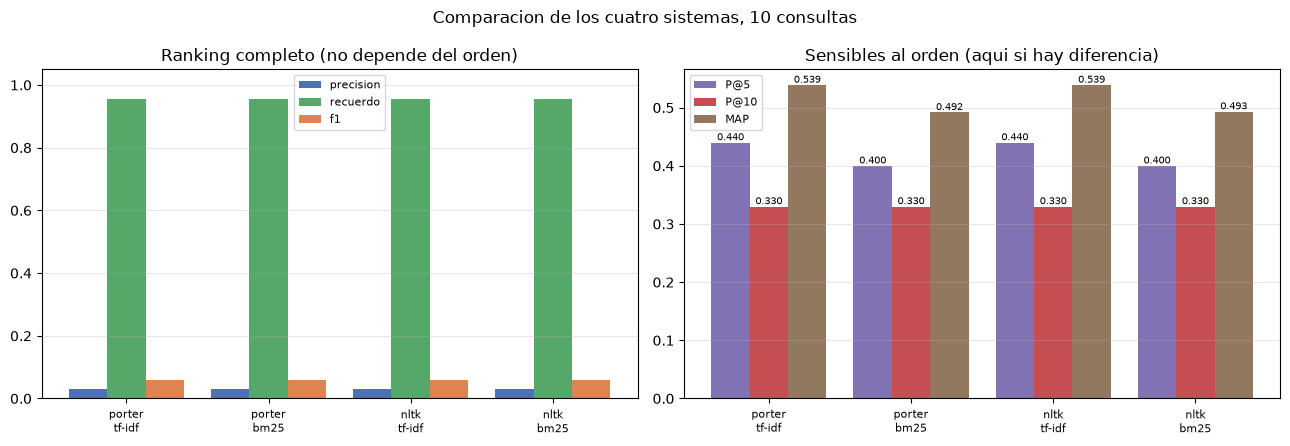

In [281]:
graficar_comparacion(resumen)

In [282]:
print("--- Posiciones de los relevantes, sistema por sistema ---\n")
display(posiciones_relevantes(sims, relevancias, count=10).round(4))

--- Posiciones de los relevantes, sistema por sistema ---



,query,sistema,hallados,posiciones,AP
0,1,porter tf-idf,7/7,"1, 3, 4, 6, 7, 8, 10",0.7497
1,1,porter bm25,7/7,"2, 5, 6, 7, 8, 9, 12",0.5495
2,1,nltk tf-idf,7/7,"1, 3, 4, 6, 7, 8, 10",0.7497
3,1,nltk bm25,7/7,"2, 5, 6, 7, 8, 9, 12",0.5495
4,2,porter tf-idf,2/2,"1, 5",0.7000
5,2,porter bm25,2/2,"3, 5",0.3667
6,2,nltk tf-idf,2/2,"1, 5",0.7000
7,2,nltk bm25,2/2,"3, 5",0.3667
8,3,porter tf-idf,3/4,"3, 13, 41",0.1401
9,3,porter bm25,3/4,"7, 11, 23",0.1138


In [283]:
# El detalle por consulta de un solo sistema, por si se quiere ver
display(metricas_por_query(sim_porter_tfidf, relevancias,
                           count=10).round(4))

,recuperados,relevantes,precision,recuerdo,f1,P@5,P@10,AP
query,,,,,,,,
1,147,7,0.0476,1.00,0.0909,0.6,0.7,0.7497
2,287,2,0.0070,1.00,0.0138,0.4,0.2,0.7000
3,312,4,0.0096,0.75,0.0190,0.2,0.1,0.1401
4,371,5,0.0135,1.00,0.0266,0.0,0.1,0.0487
5,135,5,0.0296,0.80,0.0571,0.0,0.0,0.0418
6,206,9,0.0437,1.00,0.0837,1.0,0.7,0.9114
7,345,2,0.0058,1.00,0.0115,0.0,0.0,0.0305
8,196,2,0.0102,1.00,0.0202,0.4,0.2,1.0000
9,77,8,0.1039,1.00,0.1882,1.0,0.7,0.9185


In [284]:
salidas = {
    "porter tf-idf": "out/actividad_2/rec_porter_tfidf.txt",
    "porter bm25":   "out/actividad_2/rec_porter_bm25.txt",
    "nltk tf-idf":   "out/actividad_2/rec_nltk_tfidf.txt",
    "nltk bm25":     "out/actividad_2/rec_nltk_bm25.txt",
}

os.makedirs("out/actividad_2", exist_ok=True)

for nombre, archivo in salidas.items():
    n = export_recuperacion(sims[nombre], relevancias, archivo, count=10)
    kb = os.path.getsize(archivo) / 1024
    print(f"{archivo:42} {n:2} lineas  {kb:7.1f} KB")

out/actividad_2/rec_porter_tfidf.txt       10 lineas     30.5 KB
out/actividad_2/rec_porter_bm25.txt        10 lineas     30.5 KB
out/actividad_2/rec_nltk_tfidf.txt         10 lineas     30.4 KB
out/actividad_2/rec_nltk_bm25.txt          10 lineas     30.4 KB


## Actividad 3

### Query expansion

Recordar de las clases que el query expansion es agregar terminos a una  query
terminos que el user no escribio, para que esta empate con mas documentos relevantes.
Las instrucciones a detalle de la actividad estan en el README. Pero basicamente
es aplicar el metodo de Rocchio para query espansion.

La idea central de ROcchio es, como todos son vectores, la consulta se puede mover en el 
espacio, la idea es acercarla a los documentos relevantes y alejarla de los que no lo son,
esta dada por esta expresion

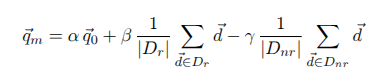

Primero recuperaremos los 100 documentos con mayor similitud coseno para cada
consulta de la tarea 2. Recordar que tenemos 4 corpus, uno con las palabras truncadas
con el algoritmo de porter, y otro con nltk, y para cada variante tenemos la matriz
pesada con tf-idf y con okapi. Trabajaremos con los 4 para comparar con lo obtenido
en la tarea pasada.

In [285]:
TOPE_RECUPERADOS = 100
SEMILLA_RELEVANTES = 3


def top_similares(sim, qid, tope=TOPE_RECUPERADOS):
    """
    Los documentos con mayor similitud coseno para una consulta.
    Solo entran los de coseno mayor que cero, o sea los que comparten
    al menos un termino con la consulta, asi que una consulta corta
    puede devolver menos de tope documentos

    Inputs:
    -------
    sim: Matriz de similitud, consultas por documentos
    qid: Identificador de la consulta, de las filas de sim
    tope: Cuantos documentos conservar, desde el mas similar

    Returns:
    -------
    Series: Ids de documento con su coseno, en orden decreciente

    """
    fila = sim.loc[qid]
    return fila[fila > 0].nlargest(tope)


def base_expansion(sim, count=10, tope=TOPE_RECUPERADOS,
                   semilla=SEMILLA_RELEVANTES):
    """
    Punto de partida de Rocchio, una entrada por consulta.
    Los relevantes no salen de TIME.REL sino de las primeras semilla
    posiciones del ranking, que es lo que pide la actividad. Los
    juicios se reservan para medir el AP al final, meterlos aqui
    seria pasarle la respuesta a la expansion

    Inputs:
    -------
    sim: Matriz de similitud, consultas por documentos
    count: Cuantas consultas incluir, desde la primera
    tope: Cuantos documentos recuperar por consulta
    semilla: Cuantas primeras posiciones se asumen relevantes

    Returns:
    -------
    dict: Id de consulta -> consulta, documentos, relevantes y rocchio

    """
    base = {}
    for qid in sim.index[:count]:
        documentos = list(top_similares(sim, qid, tope).index)
        base[qid] = {
            "consulta": qid,
            "documentos": documentos,
            "relevantes": documentos[:semilla],
            "rocchio": None,
        }

    return base

In [286]:
# Las cuatro sim_* y el dict sims quedaron armados en la actividad 2
bases = {nombre: base_expansion(sim) for nombre, sim in sims.items()}

for nombre, base in bases.items():
    tamanos = [len(e["documentos"]) for e in base.values()]
    print(f"{nombre:>14}   {len(base)} consultas   "
          f"docs por consulta: min {min(tamanos)} max {max(tamanos)}")

print("\n\n--- SANITY CHECK: primera consulta de nltk tf-idf ---\n")

ejemplo = bases["nltk tf-idf"][next(iter(bases["nltk tf-idf"]))]
print(f"consulta   : {ejemplo['consulta']}")
print(f"documentos : {len(ejemplo['documentos'])} -> "
      f"{ejemplo['documentos'][:8]} ...")
print(f"relevantes : {ejemplo['relevantes']}")
print(f"rocchio    : {ejemplo['rocchio']}")

 porter tf-idf   10 consultas   docs por consulta: min 77 max 100
   porter bm25   10 consultas   docs por consulta: min 77 max 100
   nltk tf-idf   10 consultas   docs por consulta: min 77 max 100
     nltk bm25   10 consultas   docs por consulta: min 77 max 100


--- SANITY CHECK: primera consulta de nltk tf-idf ---

consulta   : 1
documentos : 100 -> ['396', '320', '414', '418', '498', '334', '390', '434'] ...
relevantes : ['396', '320', '414']
rocchio    : None


Ahora el metodo Rocchio...

In [ ]:
ALFA_ROCCHIO = 1.0
BETA_ROCCHIO = 0.75
GAMMA_ROCCHIO = 0.15


def centroide(mat_docs, ids):
    """
    Centroide de un conjunto de documentos.
    Normaliza antes de promediar porque las filas de tf-idf y de BM25
    tienen magnitudes muy distintas entre si, y sin normalizar un
    documento largo jalaria el centroide solo por ser largo

    Inputs:
    -------
    mat_docs: Matriz documento por termino, con el pesado que se use
    ids: Ids de los documentos que forman el conjunto

    Returns:
    -------
    Series: Vector promedio, o un vector de ceros si ids va vacio

    """
    if not len(ids):
        return pd.Series(0.0, index=mat_docs.columns, dtype="float32")

    return normalizar(mat_docs.loc[ids]).mean(axis=0)


def rocchio(consulta, mat_docs, relevantes, no_relevantes,
            alfa=ALFA_ROCCHIO, beta=BETA_ROCCHIO,
            gamma=GAMMA_ROCCHIO):
    """
    Consulta expandida por la formula de Rocchio.
    Mueve el vector de la consulta hacia el centroide de lo que se
    asume relevante y lo aleja del centroide del resto

    Inputs:
    -------
    consulta: Vector binario de la consulta original
    mat_docs: Matriz documento por termino, con el pesado que se use
    relevantes: Ids que se asumen relevantes
    no_relevantes: Ids que se asumen no relevantes
    alfa: Peso de la consulta original
    beta: Peso del centroide de los relevantes
    gamma: Peso del centroide de los no relevantes

    Returns:
    -------
    Series: Consulta expandida, sin componentes negativas

    """
    norma = np.sqrt((consulta.astype("float32") ** 2).sum())
    consulta_n = consulta / (norma if norma else 1)

    nueva = (alfa * consulta_n
             + beta * centroide(mat_docs, relevantes)
             - gamma * centroide(mat_docs, no_relevantes))

    return nueva.clip(lower=0).astype("float32")


def expandir_consultas(base, mat_docs, mat_queries_bin,
                       alfa=ALFA_ROCCHIO, beta=BETA_ROCCHIO,
                       gamma=GAMMA_ROCCHIO):
    """
    Aplica Rocchio a todas las consultas de una base.
    No relevantes son los documentos del top que no entraron en la
    semilla, no la coleccion entera, solo se retroalimenta con lo que
    el sistema ya habia traido

    Inputs:
    -------
    base: Lo que devuelve base_expansion, se lee, no se modifica
    mat_docs: Matriz documento por termino, con el pesado que se use
    mat_queries_bin: Matriz consulta por termino, en binario
    alfa: Peso de la consulta original
    beta: Peso del centroide de los relevantes
    gamma: Peso del centroide de los no relevantes

    Returns:
    -------
    DataFrame: Consulta por termino, con las consultas ya expandidas

    """
    consultas = mat_queries_bin.reindex(columns=mat_docs.columns,
                                        fill_value=0)

    filas = {}
    for qid, entrada in base.items():
        semilla = set(entrada["relevantes"])
        resto = [doc for doc in entrada["documentos"]
                 if doc not in semilla]

        filas[qid] = rocchio(consultas.loc[qid], mat_docs,
                             entrada["relevantes"], resto,
                             alfa, beta, gamma)

    return pd.DataFrame.from_dict(filas, orient="index")


def aplicar_rocchio(base, mat_docs, mat_queries_bin, relevancias,
                    tope=TOPE_RECUPERADOS, alfa=ALFA_ROCCHIO,
                    beta=BETA_ROCCHIO, gamma=GAMMA_ROCCHIO):
    """
    Expande, vuelve a recuperar y llena el campo rocchio de base.
    El AP de antes se mide sobre los mismos tope documentos de la
    primera pasada, no sobre el ranking completo, para que las dos
    cifras se comparen sobre el mismo corte. Aqui si entran los
    juicios de TIME.REL, que es lo unico que miden y no expanden

    Inputs:
    -------
    base: Lo que devuelve base_expansion, se modifica en el lugar
    mat_docs: Matriz documento por termino, con el pesado que se use
    mat_queries_bin: Matriz consulta por termino, en binario
    relevancias: Dict de id de consulta a conjunto de ids relevantes
    tope: Cuantos documentos recuperar en la segunda pasada
    alfa: Peso de la consulta original
    beta: Peso del centroide de los relevantes
    gamma: Peso del centroide de los no relevantes

    Returns:
    -------
    DataFrame: Matriz de similitud de las consultas expandidas

    """
    nuevas = expandir_consultas(base, mat_docs, mat_queries_bin,
                                alfa, beta, gamma)
    sim_nueva = cosine_sim(mat_docs, nuevas)

    for qid, entrada in base.items():
        fila = sim_nueva.loc[qid]
        rank = list(fila[fila > 0].nlargest(tope).index)
        juicios = relevancias.get(qid, set())

        entrada["rocchio"] = {
            "documentos": rank,
            "ap_antes": precision_promedio(entrada["documentos"],
                                           juicios),
            "ap_despues": precision_promedio(rank, juicios),
        }

    return sim_nueva

In [288]:
# Cada sistema necesita su matriz de documentos y la de consultas
# binarias del mismo truncamiento
sistemas = {
    "porter tf-idf": (mat_porter_tfidf, mat_queries_porter_bin),
    "porter bm25":   (mat_porter_bm25, mat_queries_porter_bin),
    "nltk tf-idf":   (mat_nltk_tfidf, mat_queries_nltk_bin),
    "nltk bm25":     (mat_nltk_bm25, mat_queries_nltk_bin),
}

sims_rocchio = {
    nombre: aplicar_rocchio(bases[nombre], mat_docs, mat_q,
                            relevancias)
    for nombre, (mat_docs, mat_q) in sistemas.items()
}

filas = []
for nombre, base in bases.items():
    for qid, entrada in base.items():
        r = entrada["rocchio"]
        filas.append({
            "sistema": nombre,
            "query": qid,
            "orden": int(qid),
            "AP antes": r["ap_antes"],
            "AP despues": r["ap_despues"],
            "delta": r["ap_despues"] - r["ap_antes"],
        })

tabla_ap = (pd.DataFrame(filas)
            .sort_values(["sistema", "orden"])
            .drop(columns="orden")
            .reset_index(drop=True))

resumen = tabla_ap.groupby("sistema")[["AP antes", "AP despues"]].mean()
resumen["delta"] = resumen["AP despues"] - resumen["AP antes"]

print("--- MAP antes y despues de la expansion ---\n")
display(resumen.round(4))

print("\n--- AP por consulta ---\n")
display(tabla_ap.round(4))

--- MAP antes y despues de la expansion ---



,AP antes,AP despues,delta
sistema,,,
nltk bm25,0.4907,0.5090,0.0183
nltk tf-idf,0.5376,0.5618,0.0242
porter bm25,0.4893,0.5101,0.0208
porter tf-idf,0.5376,0.5618,0.0242



--- AP por consulta ---



,sistema,query,AP antes,AP despues,delta
0,nltk bm25,1,0.5495,0.5980,0.0485
1,nltk bm25,2,0.3667,0.4167,0.0500
2,nltk bm25,3,0.1138,0.1346,0.0208
3,nltk bm25,4,0.0196,0.0445,0.0249
4,nltk bm25,5,0.0482,0.0786,0.0303
5,nltk bm25,6,0.9535,0.9798,0.0263
6,nltk bm25,7,0.0625,0.0357,-0.0268
7,nltk bm25,8,1.0000,1.0000,0.0000
8,nltk bm25,9,0.9375,0.9464,0.0089
9,nltk bm25,10,0.8556,0.8556,0.0000


In [289]:
# Entregable de la actividad 3: solo la lista de AP por consulta,
# antes y despues de la expansion
RUTA_AP = "out/actividad_3/ap_por_consulta.csv"

os.makedirs(os.path.dirname(RUTA_AP), exist_ok=True)
tabla_ap.to_csv(RUTA_AP, index=False, float_format="%.6f")

kb = os.path.getsize(RUTA_AP) / 1024
print(f"{RUTA_AP:38} {len(tabla_ap):2} filas  {kb:6.1f} KB")

out/actividad_3/ap_por_consulta.csv    40 filas     1.7 KB


### Como se mueve la consulta

La expansion es un desplazamiento en el espacio de terminos, asi que
se puede ver. Cada panel proyecta a tres dimensiones, con PCA
resuelto por SVD, el top de la consulta junto con los dos centroides
y las dos versiones de la consulta.

Importante notar que:

- Las filas se normalizan antes de proyectar
- Cada panel tiene su propia proyeccion, porque cada consulta trae
  otro conjunto de documentos

In [290]:
# Paleta validada para scatter: los tres primeros slots del tema
# categorico son los que separan bien en todos los pares, tambien
# para daltonismo. El gris de la nube no cuenta como slot
SUPERFICIE_VIZ = "#fcfcfb"
TINTA_VIZ = "#52514e"
REJILLA_VIZ = "#e8e7e2"
NUBE_VIZ = "#b8b7b0"
SERIE_CONSULTA = "#2a78d6"
SERIE_SEMILLA = "#eb6834"
SERIE_JUICIO = "#1baf7a"

# Angulo de camara de los paneles en tres dimensiones
ELEV_VIZ = 18
AZIM_VIZ = -58
DIMS_PCA = 3

ESPECIALES = ("q original", "q expandida", "centroide semilla",
              "centroide resto")
ETIQUETAS_ESPECIALES = ("q", "q'", "c+", "c-")


def estilo_3d(eje, elev=ELEV_VIZ, azim=AZIM_VIZ, zoom=1.18,
              aspecto=None):
    """
    Deja un Axes3D con el estilo comun de las figuras del notebook.
    Paneles del color de la superficie, rejilla fina, camara y
    tamano de tick. Va aparte porque lo usan las tres figuras en
    tres dimensiones y no tiene caso repetirlo

    Inputs:
    -------
    eje: Axes3D a estilizar
    elev: Elevacion de la camara
    azim: Azimut de la camara
    zoom: Cuanto llena el cubo su recuadro, que por omision es poco
    aspecto: Proporciones del cubo, None deja las de los datos

    Returns:
    -------
    None: Modifica eje en el lugar

    """
    for axis in (eje.xaxis, eje.yaxis, eje.zaxis):
        axis.set_pane_color(SUPERFICIE_VIZ)
        axis._axinfo["grid"]["color"] = REJILLA_VIZ
        axis._axinfo["grid"]["linewidth"] = 1

    eje.set_box_aspect(aspecto, zoom=zoom)
    eje.view_init(elev=elev, azim=azim)
    eje.tick_params(labelsize=6, colors=TINTA_VIZ)


def proyeccion_pca(mat, dims=DIMS_PCA):
    """
    Proyecta con PCA, resuelto por SVD.
    Normaliza las filas antes de proyectar porque el ranking se decide
    por coseno: sobre la esfera unitaria la distancia euclidiana y el
    coseno ordenan igual, asi que el dibujo si corresponde a lo que el
    sistema mide

    Inputs:
    -------
    mat: Matriz punto por termino, documentos y consultas juntos
    dims: Cuantos componentes principales conservar

    Returns:
    -------
    tuple: (coordenadas de n por dims, varianza explicada por eje)

    """
    x = normalizar(mat).to_numpy(dtype="float64")
    centrada = x - x.mean(axis=0)

    _, valores, base = np.linalg.svd(centrada, full_matrices=False)
    coords = centrada @ base[:dims].T
    varianza = valores ** 2 / (valores ** 2).sum()

    return coords, varianza[:dims]


def puntos_rocchio(entrada, mat_docs, mat_queries_bin,
                   alfa=ALFA_ROCCHIO, beta=BETA_ROCCHIO,
                   gamma=GAMMA_ROCCHIO):
    """
    Junta en una sola matriz todo lo que se va a proyectar.
    Los documentos del top mas las dos consultas y los dos centroides
    van juntos para que caigan en la misma proyeccion, que es lo unico
    que hace comparables sus posiciones

    Inputs:
    -------
    entrada: Una entrada de las que arma base_expansion
    mat_docs: Matriz documento por termino, con el pesado que se use
    mat_queries_bin: Matriz consulta por termino, en binario
    alfa: Peso de la consulta original
    beta: Peso del centroide de los relevantes
    gamma: Peso del centroide de los no relevantes

    Returns:
    -------
    DataFrame: Los documentos del top y cuatro filas mas, nombradas
               como ESPECIALES

    """
    semilla = entrada["relevantes"]
    resto = [doc for doc in entrada["documentos"]
             if doc not in set(semilla)]
    consulta = mat_queries_bin.reindex(columns=mat_docs.columns,
                                       fill_value=0).loc[
                                           entrada["consulta"]]

    extra = pd.DataFrame({
        ESPECIALES[0]: consulta.astype("float32"),
        ESPECIALES[1]: rocchio(consulta, mat_docs, semilla, resto,
                               alfa, beta, gamma),
        ESPECIALES[2]: centroide(mat_docs, semilla),
        ESPECIALES[3]: centroide(mat_docs, resto),
    }).T

    return pd.concat([mat_docs.loc[entrada["documentos"]], extra])


def graficar_rocchio(entrada, mat_docs, mat_queries_bin, juicios,
                     eje=None, leyenda=True):
    """
    Dibuja en tres dimensiones el desplazamiento de una consulta.
    La flecha va de la consulta original a la expandida. Si Rocchio
    hizo lo que debia, la punta queda mas cerca de los triangulos, que
    son los relevantes de verdad, y no solo de la semilla

    Inputs:
    -------
    entrada: Una entrada de base, ya pasada por aplicar_rocchio
    mat_docs: Matriz documento por termino, con el pesado que se use
    mat_queries_bin: Matriz consulta por termino, en binario
    juicios: Conjunto de ids relevantes segun TIME.REL
    eje: Axes3D donde dibujar, None para abrir una figura propia
    leyenda: Si dibuja la leyenda en este panel

    Returns:
    -------
    None: Dibuja sobre eje

    """
    puntos = puntos_rocchio(entrada, mat_docs, mat_queries_bin)
    coords, varianza = proyeccion_pca(puntos)
    pos = pd.DataFrame(coords, index=puntos.index,
                       columns=["x", "y", "z"])

    semilla = set(entrada["relevantes"])
    aciertos = [doc for doc in entrada["documentos"]
                if doc in juicios and doc not in semilla]
    nube = [doc for doc in entrada["documentos"]
            if doc not in juicios and doc not in semilla]

    if eje is None:
        figura = plt.figure(figsize=(8, 7))
        eje = figura.add_subplot(projection="3d")

    # depthshade apagado a proposito: matplotlib desatura por
    # profundidad y eso rompe la separacion de la paleta
    for ids, color, marca, tam, nombre in (
            (nube, NUBE_VIZ, "o", 45, "resto del top"),
            (aciertos, SERIE_JUICIO, "^", 70,
             "relevante en TIME.REL"),
            (list(semilla), SERIE_SEMILLA, "s", 95,
             "semilla, los 3 primeros")):
        eje.scatter(pos.loc[ids, "x"], pos.loc[ids, "y"],
                    pos.loc[ids, "z"], s=tam, color=color,
                    marker=marca, depthshade=False,
                    edgecolors=SUPERFICIE_VIZ,
                    linewidths=0 if marca == "o" else 1.2,
                    alpha=0.6 if marca == "o" else 1.0, label=nombre)

    for clave, color, marca, relleno, nombre in (
            (ESPECIALES[2], SERIE_SEMILLA, "X", True,
             "centroide semilla"),
            (ESPECIALES[3], NUBE_VIZ, "X", True, "centroide resto"),
            (ESPECIALES[0], SERIE_CONSULTA, "o", False,
             "consulta original"),
            (ESPECIALES[1], SERIE_CONSULTA, "*", True,
             "consulta expandida")):
        eje.scatter(pos.loc[clave, "x"], pos.loc[clave, "y"],
                    pos.loc[clave, "z"],
                    s=260 if marca == "*" else 140, marker=marca,
                    color=color if relleno else SUPERFICIE_VIZ,
                    edgecolors=SUPERFICIE_VIZ if relleno else color,
                    linewidths=2, depthshade=False, label=nombre)

    origen = pos.loc[ESPECIALES[0]]
    destino = pos.loc[ESPECIALES[1]]
    eje.quiver(origen["x"], origen["y"], origen["z"],
               destino["x"] - origen["x"],
               destino["y"] - origen["y"],
               destino["z"] - origen["z"],
               color=SERIE_CONSULTA, linewidth=2,
               arrow_length_ratio=0.16)

    for clave, texto in zip(ESPECIALES, ETIQUETAS_ESPECIALES):
        eje.text(pos.loc[clave, "x"], pos.loc[clave, "y"],
                 pos.loc[clave, "z"], f"  {texto}", fontsize=9,
                 color=TINTA_VIZ)

    r = entrada["rocchio"]
    eje.set_title(f"consulta {entrada['consulta']}   "
                  f"AP {r['ap_antes']:.4f} -> {r['ap_despues']:.4f}",
                  fontsize=10, color=TINTA_VIZ, y=0.97)
    for poner, num in ((eje.set_xlabel, 0), (eje.set_ylabel, 1),
                       (eje.set_zlabel, 2)):
        poner(f"PC{num + 1}, {varianza[num]:.1%}", fontsize=8,
              color=TINTA_VIZ)

    estilo_3d(eje)

    if leyenda:
        eje.legend(fontsize=7, frameon=False, loc="best")


def componer_rocchio(queries, bases, sistemas, relevancias, sistema,
                     figsize=(14, 12), cols=2, wspace=0.04):
    """
    Arma la figura de paneles de Rocchio.
    Va aparte porque se usa dos veces con tamanos distintos: la
    version de exploracion, con cuatro consultas y grande, y la del
    reporte, con dos y del ancho de la pagina. A ancho de pagina un
    lienzo de 14 pulgadas encoge las etiquetas a la mitad y no se lee

    Inputs:
    -------
    queries: Ids de las consultas a dibujar
    bases: Dict de sistema a su base ya expandida
    sistemas: Dict de sistema a (mat_docs, mat_queries_bin)
    relevancias: Dict de consulta a sus ids relevantes
    sistema: Cual de los cuatro sistemas dibujar
    figsize: Tamano del lienzo en pulgadas
    cols: Cuantos paneles por renglon
    wspace: Aire horizontal entre paneles. Un Axes3D reserva una
            caja bastante mas grande que el cubo visible, asi que
            con poco aire los ejes de un panel se meten en el de
            al lado

    Returns:
    -------
    Figure: La figura ya armada

    """
    mat_docs, mat_q = sistemas[sistema]
    renglones = -(-len(queries) // cols)

    fig, ejes = plt.subplots(renglones, cols, figsize=figsize,
                             squeeze=False,
                             subplot_kw={"projection": "3d"})
    for eje, qid in zip(ejes.ravel(), queries):
        graficar_rocchio(bases[sistema][qid], mat_docs, mat_q,
                         relevancias.get(qid, set()), eje=eje,
                         leyenda=False)

    # La leyenda va en la figura y no en un panel: con loc="best"
    # acababa encima de los puntos del primero
    marcas, nombres = ejes[0][0].get_legend_handles_labels()
    fig.legend(marcas, nombres, loc="upper center", ncol=4,
               fontsize=8, frameon=False, bbox_to_anchor=(0.5, 0.955))

    fig.suptitle(f"Desplazamiento de la consulta por Rocchio, "
                 f"{sistema}", fontsize=12, color=TINTA_VIZ, y=0.995)
    # tight_layout no sabe medir un cubo en perspectiva y deja
    # margenes enormes, asi que los margenes van a mano
    fig.subplots_adjust(left=0.02, right=0.97, top=0.89, bottom=0.02,
                        wspace=wspace, hspace=0.10)

    return fig


In [ ]:
# Dos consultas donde Rocchio ayudo y dos donde estorbo, que son las
# que explican el promedio
QUERIES_MUESTRA = ("1", "10", "5", "7")
SISTEMA_MUESTRA = "nltk tf-idf"

fig_rocchio = componer_rocchio(QUERIES_MUESTRA, bases, sistemas,
                               relevancias, SISTEMA_MUESTRA)
plt.show()

### Semantica distribucional

Igual voy a incluir esto porque se me hace interesante y quiero ver como funciona :P

La tercera via de la expansion de consultas, la automatica. Las
asociaciones entre palabras salen de la coleccion misma, no de un
tesauro externo ni del usuario. Se parte de la matriz de terminos
contra documentos y se multiplica por su transpuesta:

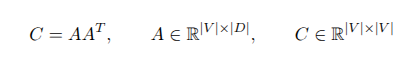

Con A binaria, cada celda de C dice en cuantos contextos aparecen
juntas dos palabras, y la diagonal queda con la frecuencia de
contexto de cada termino, porque un termino comparte consigo mismo
todos sus contextos

In [292]:
CAMPO_CONTEXTO = "texto_porter_nltk"
# Un solo tamano no dice nada: lo que informa es como cambian
# los vecinos al apretar el contexto
TAMS_VENTANA = (12,)
VECINOS_TOPE = 8
# Un termino que aparece en un solo contexto comparte el 100% de sus
# contextos con lo que sea que lo acompane, y el coseno lo premia.
# Sin este piso las listas se llenan de rarezas de una aparicion
DF_MINIMA = 5


def contextos_documento(docs, campo=CAMPO_CONTEXTO):
    """
    Un contexto por documento, que es el caso grande.

    Inputs:
    -------
    docs: Lista de documentos ya procesados
    campo: Llave del texto truncado que se va a usar

    Returns:
    -------
    list: Una lista de terminos por documento

    """
    return [doc[campo].split() for doc in docs]


def contextos_ventana(docs, tam, campo=CAMPO_CONTEXTO):
    """
    Parte cada documento en ventanas de tam palabras.
    Las ventanas no se traslapan y la ultima de cada documento queda
    corta. Traslaparlas suaviza el conteo, pero tambien mete la misma
    pareja de palabras varias veces, que es justo lo que C cuenta

    Inputs:
    -------
    docs: Lista de documentos ya procesados
    tam: Cuantas palabras por ventana
    campo: Llave del texto truncado que se va a usar

    Returns:
    -------
    list: Una lista de terminos por ventana

    """
    trozos = []
    for doc in docs:
        palabras = doc[campo].split()
        trozos.extend(palabras[i:i + tam]
                      for i in range(0, len(palabras), tam))

    return trozos


def matriz_a(contextos, terminos=None):
    """
    La matriz A de la formula, termino por contexto.
    Binaria: 1 si el termino aparece en ese contexto. Los terminos
    van ordenados alfabeticamente para que A y C sean reproducibles
    entre corridas y no dependan del orden en que se leyo la
    coleccion

    Inputs:
    -------
    contextos: Lista de listas de terminos, una por contexto
    terminos: Vocabulario a usar, None para tomarlo de contextos

    Returns:
    -------
    DataFrame: |V| por |D|, indexada por termino

    """
    if terminos is None:
        terminos = sorted({t for ctx in contextos for t in ctx})
    posicion = {termino: i for i, termino in enumerate(terminos)}

    a = np.zeros((len(terminos), len(contextos)), dtype="float32")
    for j, ctx in enumerate(contextos):
        for termino in set(ctx):
            i = posicion.get(termino)
            if i is not None:
                a[i, j] = 1.0

    return pd.DataFrame(a, index=terminos)


def matriz_coocurrencia(a):
    """
    C = A A^T completa.
    El producto va en float32 porque asi lo hace BLAS y es dos
    ordenes de magnitud mas rapido que en enteros. Las cuentas caben
    exactas: float32 representa sin error los enteros hasta 2^24 y
    aqui el maximo posible es el numero de contextos

    Inputs:
    -------
    a: Matriz A que devuelve matriz_a

    Returns:
    -------
    DataFrame: |V| por |V|, simetrica, con la frecuencia de contexto
               de cada termino en la diagonal

    """
    bruto = a.to_numpy(dtype="float32")
    c = bruto @ bruto.T

    return pd.DataFrame(c.astype("int32"), index=a.index,
                        columns=a.index, copy=False)


def vecinos(c, termino, tope=VECINOS_TOPE, coseno=True,
            df_min=DF_MINIMA):
    """
    Los terminos que mas contextos comparten con termino.
    Con coseno se divide entre la raiz del producto de las dos
    frecuencias de contexto, que para filas binarias es exactamente
    el coseno entre ellas. Sin normalizar la lista la copan las
    palabras mas comunes de la coleccion, que comparten contexto con
    todo y por eso no dicen nada. Todo sale de C: la normalizacion
    usa su diagonal

    Inputs:
    -------
    c: Matriz de coocurrencia completa
    termino: Termino del que se buscan vecinos
    tope: Cuantos vecinos devolver
    coseno: False deja el conteo crudo de contextos compartidos
    df_min: Frecuencia de contexto minima para entrar a la lista

    Returns:
    -------
    Series: Vecino -> peso, en orden decreciente

    """
    diagonal = pd.Series(np.diagonal(c.to_numpy()), index=c.index)

    fila = c.loc[termino].drop(termino)
    fila = fila[(fila > 0) & (diagonal.drop(termino) >= df_min)]

    if coseno:
        fila = fila / np.sqrt(diagonal[termino]
                              * diagonal[fila.index])

    # sort_index antes y sort_values estable despues: los empates
    # quedan en orden alfabetico, asi la lista no depende del orden
    # en que se recorrio el vocabulario
    return (fila.sort_index()
            .sort_values(ascending=False, kind="stable")
            .head(tope))


def comparar_contextos(matrices, terminos, tope=VECINOS_TOPE):
    """
    Vecinos de cada termino bajo cada tamano de contexto.
    Puestos uno debajo del otro es donde se ve si el tamano cambia el
    tipo de relacion, que es lo que se queria probar

    Inputs:
    -------
    matrices: Dict de nombre de contexto a su matriz C
    terminos: Terminos a comparar
    tope: Cuantos vecinos por fila

    Returns:
    -------
    DataFrame: Indexado por termino y contexto, un vecino por columna

    """
    filas = {}
    for nombre, c in matrices.items():
        for termino in terminos:
            if termino not in c.index:
                continue
            filas[(termino, nombre)] = [
                f"{otro} {peso:.2f}"
                for otro, peso in vecinos(c, termino, tope).items()]

    tabla = pd.DataFrame(filas).T.sort_index()
    tabla.columns = [f"#{i + 1}" for i in tabla.columns]
    tabla.index.names = ["termino", "contexto"]

    return tabla

In [293]:
# Stems de NLTK: kennedy queda en kennedi, y todos tienen
# frecuencia de documento suficiente para que la comparacion tenga
# de donde salir
TERMINOS_MUESTRA = ("nuclear", "soviet", "africa", "kennedi")

contextos = {"documento": contextos_documento(docs)}
for tam in TAMS_VENTANA:
    # El cero a la izquierda es para que la ventana 05 se ordene
    # antes que la 12 y no al reves
    contextos[f"ventana {tam:02d}"] = contextos_ventana(docs, tam)

matrices_c = {}
for nombre, ctx in contextos.items():
    inicio = time.perf_counter()
    a = matriz_a(ctx)
    c = matriz_coocurrencia(a)
    matrices_c[nombre] = c

    bruto = c.to_numpy()
    llenas = np.count_nonzero(bruto)
    print(f"{nombre:>11}: A {a.shape[0]} x {a.shape[1]}   "
          f"C {c.shape[0]} x {c.shape[1]}")
    print(f"{'':>11}  {bruto.nbytes / 1e9:.2f} GB, "
          f"{llenas / bruto.size:.2%} de celdas distintas de cero, "
          f"{time.perf_counter() - inicio:.1f} s")

    del a

  documento: A 16623 x 423   C 16623 x 16623
             1.11 GB, 7.02% de celdas distintas de cero, 0.4 s
 ventana 12: A 16623 x 10530   C 16623 x 16623
             1.11 GB, 0.41% de celdas distintas de cero, 1.8 s


In [294]:
# Pedazos de C, que en tamano completo no cabe en pantalla
ESQUINA = 10

c_doc = matrices_c["documento"]
df_contexto = pd.Series(np.diagonal(c_doc.to_numpy()),
                        index=c_doc.index)
frecuentes = list(df_contexto.nlargest(ESQUINA).index)

print(f"--- Las primeras {ESQUINA} filas y columnas de C ---")
print("contexto documento, la esquina tal cual sale\n")
display(c_doc.iloc[:ESQUINA, :ESQUINA])

# El vocabulario va ordenado alfabeticamente y esa esquina cae toda
# en numeros, que aparecen en un documento o dos. Es la misma matriz
# vista en terminos frecuentes
print(f"\n--- Otras {ESQUINA} filas y columnas: los terminos que "
      f"salen en mas documentos ---")
print("la diagonal es en cuantos documentos aparece cada termino\n")
display(c_doc.loc[frecuentes, frecuentes])

for nombre, c in matrices_c.items():
    print(f"\n--- Bloque de C, contexto {nombre} ---\n")
    display(c.loc[list(TERMINOS_MUESTRA), list(TERMINOS_MUESTRA)])

print("\n\n--- Una fila entera de C, sin normalizar ---\n")

fila = c_doc.loc["nuclear"]
print(f"terminos que acompanan a nuclear en algun documento: "
      f"{int((fila > 0).sum())} de {len(fila)}")
print("los mas altos son las palabras mas comunes de la coleccion, "
      "y por eso hace falta el coseno\n")
display(fila[fila > 0].sort_values(ascending=False).head(12))

--- Las primeras 10 filas y columnas de C ---
contexto documento, la esquina tal cual sale



,00,1,"1,000","1,000,000","1,000-year-old","1,000th","1,000to-1","1,014","1,100","1,100,000"
00,1,0,0,0,0,0,0,0,0,0
1,0,47,5,2,1,0,0,0,0,0
"1,000",0,5,25,1,0,0,0,0,1,1
"1,000,000",0,2,1,8,0,0,0,0,0,0
"1,000-year-old",0,1,0,0,2,0,0,0,0,0
"1,000th",0,0,0,0,0,1,0,0,0,0
"1,000to-1",0,0,0,0,0,0,1,0,0,0
"1,014",0,0,0,0,0,0,0,1,0,0
"1,100",0,0,1,0,0,0,0,0,2,0
"1,100,000",0,0,1,0,0,0,0,0,0,2



--- Otras 10 filas y columnas: los terminos que salen en mas documentos ---
la diagonal es en cuantos documentos aparece cada termino



,new,govern,nation,u.,communist,minist,parti,countri,forc,war
new,249,146,133,111,103,113,111,109,100,92
govern,146,231,125,109,97,116,108,112,103,96
nation,133,125,195,99,79,97,89,91,85,76
u.,111,109,99,186,83,73,60,77,99,88
communist,103,97,79,83,168,54,80,76,71,78
minist,113,116,97,73,54,167,82,80,71,58
parti,111,108,89,60,80,82,165,67,58,61
countri,109,112,91,77,76,80,67,162,72,74
forc,100,103,85,99,71,71,58,72,161,76
war,92,96,76,88,78,58,61,74,76,153



--- Bloque de C, contexto documento ---



,nuclear,soviet,africa,kennedi
nuclear,44,24,6,14
soviet,24,91,10,13
africa,6,10,51,7
kennedi,14,13,7,41



--- Bloque de C, contexto ventana 12 ---



,nuclear,soviet,africa,kennedi
nuclear,111,5,0,2
soviet,5,240,1,2
africa,0,1,105,1
kennedi,2,2,1,71




--- Una fila entera de C, sin normalizar ---

terminos que acompanan a nuclear en algun documento: 5289 de 16623
los mas altos son las palabras mas comunes de la coleccion, y por eso hace falta el coseno



nuclear    44
u.         35
west       29
forc       29
nation     27
foreign    27
new        26
minist     25
soviet     24
nato       24
british    24
red        22
Name: nuclear, dtype: int32

In [295]:
# El peso es el coseno entre las filas binarias de A, no el conteo
# crudo, por eso va entre 0 y 1
with pd.option_context("display.max_colwidth", 22):
    display(comparar_contextos(matrices_c, TERMINOS_MUESTRA))

#1            #2              #3  \
termino contexto                                                    
africa  documento      african 0.58  africa' 0.50      black 0.50   
        ventana 12       south 0.16     asia 0.13      latin 0.13   
kennedi documento   washington 0.49   presid 0.44         u. 0.41   
        ventana 12      presid 0.23     john 0.17  administr 0.14   
nuclear documento         nato 0.57   deterr 0.56     polari 0.51   
        ventana 12      deterr 0.26   weapon 0.19    warhead 0.17   
soviet  documento       moscow 0.72  russian 0.69     russia 0.63   
        ventana 12       union 0.14   moscow 0.10    russian 0.10   

                                  #4              #5              #6  \
termino contexto                                                       
africa  documento         white 0.42      latin 0.34     nation 0.33   
        ventana 12      central 0.11  rhodesia' 0.10      black 0.10   
kennedi documento   washington' 0.38       nato 0.37    strateg 0.35   
        ventana 12        devis 0.11    halfway 0.10        let 0.09   
nuclear documento    multilater 0.43    warhead 0.43     missil 0.42   
        ventana 12         nato 0.16         u. 0.16     multin 0.13   
soviet  documento    khrushchev 0.55     nikita 0.54  communist 0.46   
        ventana 12      kremlin 0.10     russia 0.09       bloc 0.09   

                              #7               #8  
termino contexto                                   
africa  documento   countri 0.33       proud 0.33  
        ventana 12  america 0.10  schweitzer 0.09  
kennedi documento    atlant 0.35      intent 0.35  
        ventana 12   martyr 0.09       mourn 0.08  
nuclear documento     europ 0.42        alli 0.41  
        ventana 12    nato' 0.12        test 0.12  
soviet  documento   kremlin 0.41        west 0.41  
        ventana 12    agent 0.09  khrushchev 0.08

### Visualizando

Un termino es una fila de A: un vector binario que dice en que
contextos aparece. El coseno de la tabla de arriba es el angulo entre
dos de esas filas. Aqui se dibujan siete de ellas, el termino ancla,
sus tres vecinos mas cercanos y tres terminos que no comparten ni un
contexto con el


In [ ]:
# Los vectores caen todos en el orteante positivo, asi que desde
# el angulo de Rocchio se ven amontonados. Desde este se separan
AZIM_VECTORES = -115


def coseno_contra(c, termino, otros):
    """
    Coseno entre un termino y otros, leido de C

    Inputs:
    -------
    c: Matriz de coocurrencia completa
    termino: Termino ancla
    otros: Terminos contra los que medir

    Returns:
    -------
    Series: Termino -> coseno contra el ancla

    """
    otros = list(otros)
    propio = c.loc[termino, termino]
    diagonal = pd.Series([c.loc[o, o] for o in otros], index=otros)

    return c.loc[termino, otros] / np.sqrt(propio * diagonal)


def terminos_ajenos(c, termino, tope=3, df_min=DF_MINIMA):
    """
    Terminos frecuentes que no comparten ni un contexto con termino

    Inputs:
    -------
    c: Matriz de coocurrencia completa
    termino: Termino ancla
    tope: Cuantos devolver
    df_min: Frecuencia de contexto minima

    Returns:
    -------
    list: Ids de termino, del mas frecuente al menos

    """
    diagonal = pd.Series(np.diagonal(c.to_numpy()), index=c.index)
    sin_cruce = diagonal[(c.loc[termino] == 0) & (diagonal >= df_min)]

    return list(sin_cruce.nlargest(tope).index)


def proyeccion_vectores(mat, dims=3):
    """
    Proyecta vectores conservando el origen

    Inputs:
    -------
    mat: Matriz punto por dimension
    dims: Cuantas direcciones principales conservar

    Returns:
    -------
    DataFrame: Una fila por vector, dims columnas

    """
    x = normalizar(mat).to_numpy(dtype="float64")
    _, _, base = np.linalg.svd(x, full_matrices=False)

    return pd.DataFrame(x @ base[:dims].T, index=mat.index,
                        columns=["x", "y", "z"][:dims])


def graficar_vectores(a, c, termino, parecidos, ajenos,
                      eje=None, leyenda=True, elev=ELEV_VIZ,
                      azim=AZIM_VECTORES):
    """
    Las flechas de un termino, sus vecinos y unos ajenos

    Inputs:
    -------
    a: Matriz A del contexto que se quiere ver
    c: Matriz C del mismo contexto, para los cosenos
    termino: Termino ancla
    parecidos: Terminos cercanos
    ajenos: Terminos sin contexto en comun
    eje: Axes3D donde dibujar, None para abrir una figura propia
    leyenda: Si dibuja la leyenda en el propio eje
    elev: Elevacion de la camara
    azim: Azimut de la camara

    Returns:
    -------
    None: Dibuja sobre eje

    """
    etiquetas = [termino] + list(parecidos) + list(ajenos)
    pos = proyeccion_vectores(a.loc[etiquetas])
    cosenos = coseno_contra(c, termino, etiquetas)
    lim = float(np.abs(pos.to_numpy()).max()) * 1.3

    if eje is None:
        figura = plt.figure(figsize=(9, 8))
        eje = figura.add_subplot(projection="3d")

    grupos = ((termino, [termino], SERIE_CONSULTA, 3.0),
              ("parecidos", list(parecidos), SERIE_SEMILLA, 2.0),
              ("sin contexto en comun", list(ajenos), NUBE_VIZ, 2.0))

    k = 0
    for nombre, claves, color, grosor in grupos:
        for i, clave in enumerate(claves):
            punto = pos.loc[clave]
            eje.quiver(0, 0, 0, punto["x"], punto["y"], punto["z"],
                       color=color, linewidth=grosor,
                       arrow_length_ratio=0.12,
                       label=nombre if i == 0 else None)
            eje.scatter(punto["x"], punto["y"], punto["z"], s=45,
                        color=color, depthshade=False)
            # Dos vectores parecidos caen casi en el mismo pixel
            # y sus etiquetas se encimaban. Cada una se desplaza en
            # altura segun su lugar en la lista
            eje.text(punto["x"], punto["y"],
                     punto["z"] + lim * 0.12 * (k - 3),
                     f"  {clave} {cosenos[clave]:.2f}", fontsize=9,
                     color=TINTA_VIZ)
            k += 1

    eje.scatter([0], [0], [0], s=40, color=TINTA_VIZ)

    # quiver no mueve los limites, asi que sin esto las flechas se
    # salen del cubo y no se ve nada
    eje.set_xlim(-lim, lim)
    eje.set_ylim(-lim, lim)
    eje.set_zlim(-lim, lim)

    estilo_3d(eje, elev=elev, azim=azim, zoom=1.1,
              aspecto=(1, 1, 1))

    if leyenda:
        eje.legend(fontsize=8, frameon=False, loc="upper left")

    return pos


def componer_vectores(a, c, termino, parecidos, ajenos,
                      figsize=(10, 8.5)):
    """
    Arma la figura de vectores de termino.
    Igual que componer_rocchio, existe porque se usa dos veces con
    tamanos distintos, el de exploracion y el del reporte

    Inputs:
    -------
    a: Matriz A del contexto que se quiere ver
    c: Matriz C del mismo contexto, para los cosenos
    termino: Termino ancla
    parecidos: Terminos cercanos
    ajenos: Terminos sin contexto en comun
    figsize: Tamano del lienzo en pulgadas

    Returns:
    -------
    tuple: (Figure, DataFrame de las posiciones proyectadas)

    """
    fig = plt.figure(figsize=figsize)
    eje = fig.add_subplot(projection="3d")
    pos = graficar_vectores(a, c, termino, parecidos, ajenos, eje=eje,
                            leyenda=False)

    # La leyenda a nivel de figura, que dentro del eje tapa las
    # flechas
    marcas, nombres = eje.get_legend_handles_labels()
    fig.legend(marcas, nombres, loc="upper center", ncol=3,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0.93))

    fig.suptitle(f"Vectores de termino. El numero es el coseno real "
                 f"contra {termino}", fontsize=11, color=TINTA_VIZ)
    fig.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.02)

    return fig, pos


In [ ]:
TERMINO_ANCLA = "soviet"
CONTEXTO_VISTA = "documento"

a_doc = matriz_a(contextos[CONTEXTO_VISTA])
c_vista = matrices_c[CONTEXTO_VISTA]

parecidos = list(vecinos(c_vista, TERMINO_ANCLA, tope=3).index)
ajenos = terminos_ajenos(c_vista, TERMINO_ANCLA, tope=3)

print(f"ancla:     {TERMINO_ANCLA}")
print(f"parecidos: {parecidos}")
print(f"ajenos:    {ajenos}\n")

fig_vectores, pos = componer_vectores(a_doc, c_vista, TERMINO_ANCLA,
                                      parecidos, ajenos)
plt.show()

# Cuanta longitud sobrevivio: 1.00 seria que la proyeccion no
# deformo nada, y todo lo que falte es distorsion del dibujo
largos = np.sqrt((pos ** 2).sum(axis=1))
print("\nlongitud conservada por la proyeccion, de 1.0:")
for clave, largo in largos.items():
    print(f"  {clave:<12} {largo:.2f}")

### Figuras del reporte

Las tres figuras que usa el reporte de la actividad 3 salen de aqui,
no de una captura de pantalla, para que se puedan regenerar. Van en
PDF porque es vectorial y no se pixela al escalarlas en LaTeX.

In [ ]:
RUTA_FIGURAS = "../reportes"


def graficar_ap_rocchio(tabla, sistema, eje=None,
                        figsize=(9, 3.6)):
    """
    AP antes y despues de la expansion, consulta por consulta.
    Dos barras por consulta en vez de una de diferencia, porque el
    nivel importa: subir de 0.03 a 0.05 y subir de 0.85 a 0.95 son
    la misma diferencia y no significan lo mismo

    Inputs:
    -------
    tabla: Lo que arma la celda de AP, con sistema, query y las dos
           columnas de AP
    sistema: Cual de los cuatro sistemas graficar
    eje: Axes donde dibujar, None para abrir una figura propia
    figsize: Tamano del lienzo en pulgadas, si se abre figura

    Returns:
    -------
    Figure: La figura que contiene el eje

    """
    datos = (tabla[tabla["sistema"] == sistema]
             .assign(orden=lambda d: d["query"].astype(int))
             .sort_values("orden"))

    if eje is None:
        figura, eje = plt.subplots(figsize=figsize)
    else:
        figura = eje.get_figure()

    x = np.arange(len(datos))
    ancho = 0.38

    for correr, columna, color in ((-1, "AP antes", NUBE_VIZ),
                                   (1, "AP despues", SERIE_CONSULTA)):
        eje.bar(x + correr * ancho / 2, datos[columna], ancho,
                label=columna, color=color)

    eje.set_xticks(x)
    eje.set_xticklabels(datos["query"])
    eje.set_xlabel("consulta", fontsize=9, color=TINTA_VIZ)
    eje.set_ylabel("AP", fontsize=9, color=TINTA_VIZ)
    eje.set_ylim(0, 1.05)
    eje.grid(axis="y", color=REJILLA_VIZ, linewidth=1)
    eje.set_axisbelow(True)
    for lado in ("top", "right"):
        eje.spines[lado].set_visible(False)
    eje.tick_params(labelsize=8, colors=TINTA_VIZ)
    eje.legend(fontsize=8, frameon=False, loc="upper left")
    eje.set_title(f"Precision promedio antes y despues de Rocchio, "
                  f"{sistema}", fontsize=10, color=TINTA_VIZ)

    return figura

In [ ]:
# Las figuras del reporte se rearman mas chicas: a ancho de pagina,
# un lienzo de 14 pulgadas encoge las etiquetas a menos de la mitad.
# Las dos de Rocchio van al 85% del ancho en el .tex, asi que su
# lienzo baja en esa misma proporcion y el texto se ve igual de
# grande que en la de vectores, que si va a ancho completo
QUERIES_REPORTE = ("1", "7")
ESCALA_ROCCHIO = 0.85

os.makedirs(RUTA_FIGURAS, exist_ok=True)

fig_ap = graficar_ap_rocchio(
    tabla_ap, SISTEMA_MUESTRA,
    figsize=(9 * ESCALA_ROCCHIO, 3.6 * ESCALA_ROCCHIO))
fig_rocchio_rep = componer_rocchio(QUERIES_REPORTE, bases, sistemas,
                                   relevancias, SISTEMA_MUESTRA,
                                   figsize=(9.5 * ESCALA_ROCCHIO,
                                            5.0 * ESCALA_ROCCHIO),
                                   wspace=0.22)
fig_vectores_rep, _ = componer_vectores(a_doc, c_vista,
                                        TERMINO_ANCLA, parecidos,
                                        ajenos, figsize=(7, 6))
plt.show()

figuras = {
    "rocchio_ap.pdf": fig_ap,
    "rocchio_desplazamiento.pdf": fig_rocchio_rep,
    "vectores_termino.pdf": fig_vectores_rep,
}

for nombre, figura in figuras.items():
    ruta = f"{RUTA_FIGURAS}/{nombre}"
    figura.savefig(ruta, bbox_inches="tight")
    print(f"{ruta:42} {os.path.getsize(ruta) / 1024:7.1f} KB")

## Clustering de la coleccion

Se menciona brevemente el clustering de la coleccion, ya que puede ser muy util
para agrupar antes de buscar o para el clustering de resultados.

In [ ]:
K_CLUSTERS = 12
CLUSTERS_CONSULTADOS = 3
SEMILLA_KMEANS = 7
REINICIOS_KMEANS = 10
SIMULACIONES_AZAR = 2000


def agrupar(mat, k=K_CLUSTERS, semilla=SEMILLA_KMEANS,
            reinicios=REINICIOS_KMEANS):
    """
    k-means sobre los documentos normalizados.
    Se normaliza antes porque k-means minimiza distancia euclidiana,
    y sobre vectores de norma 1 eso equivale a maximizar el coseno,
    que es lo que usa el resto del sistema. Los centroides salen
    tambien normalizados, para poder compararlos con consultas por
    coseno

    Inputs:
    -------
    mat: Matriz documento por termino, con el pesado que se use
    k: Cuantos grupos
    semilla: Para que la corrida sea reproducible
    reinicios: Cuantas inicializaciones prueba k-means, se queda con
               la mejor

    Returns:
    -------
    tuple: (Series doc_id -> cluster, DataFrame de centroides,
            el objeto KMeans ya ajustado)

    """
    x = normalizar(mat).to_numpy(dtype="float64")

    modelo = KMeans(n_clusters=k, n_init=reinicios,
                    random_state=semilla).fit(x)

    centros = modelo.cluster_centers_
    normas = np.linalg.norm(centros, axis=1, keepdims=True)
    centros = centros / np.where(normas == 0, 1, normas)

    return (pd.Series(modelo.labels_, index=mat.index,
                      name="cluster"),
            pd.DataFrame(centros, columns=mat.columns),
            modelo)


def terminos_cluster(centroides, tope=6):
    """
    Los terminos de mayor peso en cada centroide

    Inputs:
    -------
    centroides: DataFrame de centroides
    tope: Cuantos terminos por grupo

    Returns:
    -------
    dict: Numero de cluster -> lista de terminos

    """
    return {j: list(fila.nlargest(tope).index)
            for j, fila in centroides.iterrows()}


def concentracion(asignacion, relevantes, sims=SIMULACIONES_AZAR,
                  semilla=SEMILLA_KMEANS):
    """
    Prueba de la hipotesis del cluster para una consulta.
    Mide en cuantos grupos distintos caen los documentos relevantes y
    lo compara contra repartir esa misma cantidad al azar. Sin la
    comparacion el numero no dice nada: con 12 grupos y 8 relevantes,
    caer en 6 grupos es lo que da el azar, no una concentracion

    Inputs:
    -------
    asignacion: Series doc_id -> cluster
    relevantes: Ids de documento relevantes segun TIME.REL
    sims: Cuantas repartidas al azar para el punto de comparacion
    semilla: Para que la corrida sea reproducible

    Returns:
    -------
    dict: grupos observados, grupos esperados al azar y la fraccion
          de relevantes que cae en el grupo mas poblado

    """
    presentes = [d for d in relevantes if d in asignacion.index]
    if not presentes:
        return None

    propios = asignacion.loc[presentes].to_numpy()
    rng = np.random.default_rng(semilla)
    todos = asignacion.to_numpy()

    azar = [len(np.unique(rng.choice(todos, len(presentes),
                                     replace=False)))
            for _ in range(sims)]

    return {
        "relevantes": len(presentes),
        "grupos": len(np.unique(propios)),
        "grupos al azar": float(np.mean(azar)),
        "en el mayor": np.bincount(propios).max() / len(propios),
    }


def recuperar_restringido(sim, asignacion, sim_clusters, qid,
                          n_clusters=CLUSTERS_CONSULTADOS,
                          tope=TOPE_RECUPERADOS):
    """
    Recupera mirando solo los clusters mas cercanos a la consulta

    Inputs:
    -------
    sim: Matriz de similitud consulta por documento, ya calculada
    asignacion: Series doc_id -> cluster
    sim_clusters: Matriz consulta por centroide
    qid: Consulta a recuperar
    n_clusters: Cuantos grupos se visitan
    tope: Cuantos documentos devolver

    Returns:
    -------
    tuple: (ids recuperados, cuantos documentos hubo que mirar)

    """
    elegidos = sim_clusters.loc[qid].nlargest(n_clusters).index
    candidatos = asignacion[asignacion.isin(elegidos)].index

    fila = sim.loc[qid, candidatos]

    return list(fila[fila > 0].nlargest(tope).index), len(candidatos)

In [299]:
# k-means no elige k, lo elige uno. La inercia baja siempre que sube
# k, asi que lo util es ver donde deja de bajar rapido. La silueta si
# tiene maximo, y se mide con coseno para ser coherente con el resto
mat_cluster = mat_nltk_tfidf
x_norm = normalizar(mat_cluster).to_numpy(dtype="float64")

print("  k    inercia   silueta   grupo chico   grupo grande")
for k in (5, 10, 12, 15, 20, 30):
    asig, _, modelo = agrupar(mat_cluster, k=k)
    silueta = silhouette_score(x_norm, asig.to_numpy(),
                               metric="cosine")
    tam = asig.value_counts()
    print(f"{k:>3}    {modelo.inertia_:7.2f}    {silueta:6.3f}"
          f"{tam.min():>13}{tam.max():>15}")

asignacion, centroides, modelo = agrupar(mat_cluster)

print(f"\n\n--- Los {K_CLUSTERS} grupos y de que hablan ---\n")
tam = asignacion.value_counts()
for j, terminos in sorted(terminos_cluster(centroides).items()):
    print(f"  grupo {j:>2}  ({tam[j]:>3} docs)  {' '.join(terminos)}")

  k    inercia   silueta   grupo chico   grupo grande
  5     398.84     0.023           29            195
 10     388.27     0.030           16            154
 12     381.56     0.036            8            131
 15     377.00     0.039            9             77
 20     366.63     0.044            6            168
 30     352.41     0.050            2             70


--- Los 12 grupos y de que hablan ---

  grupo  0  ( 31 docs)  african white south africa kenyatta black
  grupo  1  ( 16 docs)  tori wilson labor macmillan harold labor'
  grupo  2  ( 15 docs)  baath arab aref kassem iraq nasser
  grupo  3  ( 17 docs)  sukarno malaysia borneo sarawak tunku abdul
  grupo  4  ( 21 docs)  nasser yemen egyptian arab saudi arabia
  grupo  5  ( 76 docs)  khrushchev soviet moscow chines nikita peke
  grupo  6  ( 17 docs)  nehru india kashmir pakistan india' indian
  grupo  7  ( 18 docs)  tshomb congo u.n katanga tshombe' congoles
  grupo  8  ( 30 docs)  viet buddhist diem south cong saigon
 

In [300]:
# La hipotesis del cluster, medida contra el azar
filas = []
for qid in sim_nltk_tfidf.index[:10]:
    r = concentracion(asignacion, relevancias.get(qid, set()))
    if r:
        filas.append({"query": qid, **r})

tabla_cluster = pd.DataFrame(filas).set_index("query")
print("grupos: en cuantos grupos distintos caen los relevantes")
print("grupos al azar: lo mismo, repartiendolos sin mirar el tema\n")
display(tabla_cluster.round(3))

promedio = tabla_cluster[["grupos", "grupos al azar"]].mean()
print(f"\npromedio: {promedio['grupos']:.2f} grupos observados "
      f"contra {promedio['grupos al azar']:.2f} al azar")

grupos: en cuantos grupos distintos caen los relevantes
grupos al azar: lo mismo, repartiendolos sin mirar el tema



,relevantes,grupos,grupos al azar,en el mayor
query,,,,
1,7,1,4.705,1.000
2,2,1,1.848,1.000
3,4,3,3.222,0.500
4,5,4,3.740,0.400
5,5,4,3.740,0.400
6,9,1,5.432,1.000
7,2,2,1.848,0.500
8,2,1,1.848,1.000
9,8,2,5.133,0.875



promedio: 2.00 grupos observados contra 3.58 al azar


In [301]:
# Busqueda restringida contra busqueda exhaustiva. Misma matriz de
# similitud, lo unico que cambia es a quien se le pregunta
sim_clusters = cosine_sim(centroides, mat_queries_nltk_bin)

filas = []
for qid in sim_nltk_tfidf.index[:10]:
    juicios = relevancias.get(qid, set())

    fila = sim_nltk_tfidf.loc[qid]
    completo = list(fila[fila > 0].nlargest(TOPE_RECUPERADOS).index)

    recortado, mirados = recuperar_restringido(
        sim_nltk_tfidf, asignacion, sim_clusters, qid)

    filas.append({
        "query": qid,
        "AP exhaustiva": precision_promedio(completo, juicios),
        "AP por cluster": precision_promedio(recortado, juicios),
        "docs mirados": mirados,
        "del total": mirados / len(asignacion),
    })

tabla_restringida = pd.DataFrame(filas).set_index("query")
tabla_restringida["delta"] = (tabla_restringida["AP por cluster"]
                              - tabla_restringida["AP exhaustiva"])
display(tabla_restringida.round(4))

medias = tabla_restringida.mean()
print(f"\nMAP exhaustiva {medias['AP exhaustiva']:.4f}   "
      f"MAP por cluster {medias['AP por cluster']:.4f}   "
      f"mirando el {medias['del total']:.1%} de la coleccion")

,AP exhaustiva,AP por cluster,docs mirados,del total,delta
query,,,,,
1,0.7497,0.7497,204,0.4823,0.0000
2,0.7000,0.7000,204,0.4823,0.0000
3,0.1401,0.1218,137,0.3239,-0.0183
4,0.0417,0.0286,104,0.2459,-0.0131
5,0.0354,0.0285,53,0.1253,-0.0069
6,0.9114,0.9114,69,0.1631,0.0000
7,0.0305,0.0000,169,0.3995,-0.0305
8,1.0000,1.0000,56,0.1324,0.0000
9,0.9185,0.8750,50,0.1182,-0.0435



MAP exhaustiva 0.5376   MAP por cluster 0.5264   mirando el 26.2% de la coleccion


### Los grupos, vistos

Los 423 documentos proyectados a tres dimensiones con PCA, un panel
por grupo. Pintarlos todos juntos con doce colores no funciona: doce
tonos no se distinguen a simple vista, y menos con daltonismo. En vez
de eso cada panel resalta un grupo contra el resto de la coleccion en
gris, con la cruz marcando su centroide.

**La proyeccion es la misma en los doce paneles**, calculada una sola
vez sobre todos los documentos. Por eso una posicion significa lo
mismo en todos y los grupos se pueden comparar entre paneles.

Los tres ejes cargan poca varianza, asi que grupos que aqui se
encimen pueden estar perfectamente separados en el espacio completo.
La figura sirve para ver si un grupo es compacto o esta disperso, no
para medir distancias.

In [ ]:
def graficar_clusters(mat, asignacion, etiquetas, cols=4):
    """
    Un panel por grupo, todos sobre la misma proyeccion

    Inputs:
    -------
    mat: Matriz documento por termino, con el pesado que se use
    asignacion: Series doc_id -> cluster
    etiquetas: Dict de cluster a sus terminos, para los titulos
    cols: Cuantos paneles por renglon

    Returns:
    -------
    Figure: La figura ya armada

    """
    coords, varianza = proyeccion_pca(mat)
    pos = pd.DataFrame(coords, index=mat.index,
                       columns=["x", "y", "z"])

    grupos = sorted(asignacion.unique())
    renglones = -(-len(grupos) // cols)
    fig, ejes = plt.subplots(renglones, cols,
                             figsize=(3.6 * cols, 3.4 * renglones),
                             subplot_kw={"projection": "3d"})

    # Los mismos limites en los doce paneles. Sin esto cada panel se
    # autoescala a lo suyo y una posicion deja de significar lo
    # mismo de un panel a otro, que era todo el punto
    limites = [(pos[eje_].min(), pos[eje_].max())
               for eje_ in ("x", "y", "z")]

    for eje, j in zip(ejes.ravel(), grupos):
        miembros = asignacion[asignacion == j].index
        otros = asignacion[asignacion != j].index

        eje.scatter(pos.loc[otros, "x"], pos.loc[otros, "y"],
                    pos.loc[otros, "z"], s=16, color=NUBE_VIZ,
                    alpha=0.45, linewidths=0, depthshade=False)
        eje.scatter(pos.loc[miembros, "x"], pos.loc[miembros, "y"],
                    pos.loc[miembros, "z"], s=52,
                    color=SERIE_CONSULTA, depthshade=False,
                    edgecolors=SUPERFICIE_VIZ, linewidths=0.8)

        centro = pos.loc[miembros].mean()
        eje.scatter(centro["x"], centro["y"], centro["z"], s=150,
                    marker="X", color=SERIE_CONSULTA,
                    edgecolors=SUPERFICIE_VIZ, linewidths=1.5,
                    depthshade=False)

        eje.set_xlim(*limites[0])
        eje.set_ylim(*limites[1])
        eje.set_zlim(*limites[2])
        eje.set_title(f"grupo {j}, {len(miembros)} docs\n"
                      f"{' '.join(etiquetas[j][:3])}",
                      fontsize=8, color=TINTA_VIZ)
        estilo_3d(eje, zoom=1.05)

    for eje in ejes.ravel()[len(grupos):]:
        eje.set_visible(False)

    fig.suptitle(f"Los {len(grupos)} grupos sobre la misma "
                 f"proyeccion PCA. Ejes: "
                 f"{varianza[0]:.1%}, {varianza[1]:.1%} y "
                 f"{varianza[2]:.1%} de la varianza",
                 fontsize=11, color=TINTA_VIZ, y=0.995)
    fig.subplots_adjust(left=0.01, right=0.99, top=0.91, bottom=0.01,
                        wspace=0.05, hspace=0.22)

    return fig

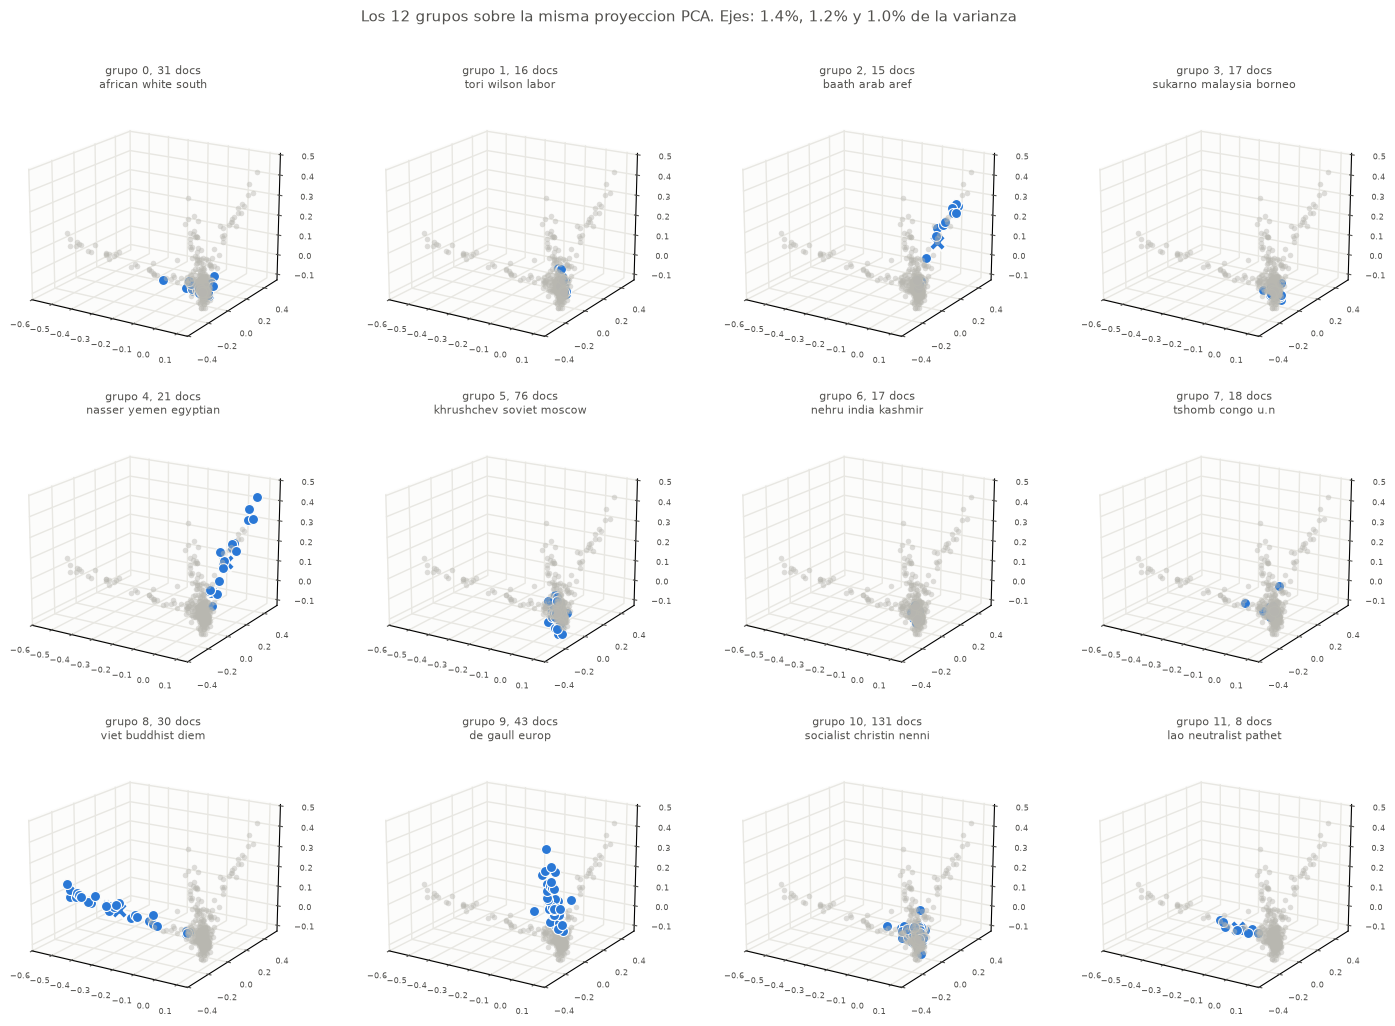

In [303]:
fig = graficar_clusters(mat_cluster, asignacion,
                        terminos_cluster(centroides))
plt.show()